# QMM: intervalo empírico, ambas ramas, EoS y masa–radio

**Seis modelos:** Dieterici y Clausius con repulsión VDW, CS y TVM. **Dos ramas:** $b_{pn}=b_n$ (`equal_b`) y $b_{pn}\ne b_n$ (`target_l`). Ambas ajustan $J=32.5$ MeV; la segunda ajusta además $L=58.9$ MeV.

- $K_0=250,255,\ldots,315$ MeV: **168 configuraciones** (14 × 6 × 2).
- Puntos críticos hadrónicos para $y=0.1,0.2,0.3,0.4,0.5$: **840 puntos**. A $y=0.5$ las dos ramas deben recuperar el mismo límite simétrico.
- EoS quarkyonic en equilibrio beta con $\Lambda=300$ MeV: 120 densidades entre $0.05n_0$ y $5n_0$, más 30 entre $5n_0$ y $15n_0$.
- Unión con corteza BPS y secuencias TOV con 260 densidades centrales por configuración.
- Figuras de $n_c$ y $T_c$ contra $\alpha$ o $c$, correlaciones $n_c(T_c)$, $P(\epsilon)$ y $M(R)$, separadas por modelo y rama.

**Ejecuta todas las celdas para completar la malla.** La EoS completa es una corrida de muchas horas. Los resultados existentes compatibles se reutilizan; los nuevos se guardan **después de cada densidad**. Puedes interrumpir la celda y volver a ejecutarla. El punto de densidad que estaba en curso se reinicia, los anteriores se conservan.

Este notebook se entrega con vistas previas de lo ya disponible; **los contadores de cobertura, no el número de curvas dibujadas, indican si la malla terminó**. Las etapas largas todavía pueden tener puntos pendientes. La banda representa el intervalo de parámetros seleccionado por $250\leq K_0\leq315$ MeV. Las envolventes EoS/M–R se construyen solo con las muestras disponibles y no son intervalos de confianza experimentales.

In [1]:
from pathlib import Path
import sys
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'src/qmm').is_dir())
sys.path.insert(0, str(ROOT / 'scripts'))
import empirical_asymmetric_suite as suite
from plot_empirical_asymmetric_suite import plot_results
import numpy as np
import pandas as pd
from IPython.display import Image, display


## Controles

Para una malla más fina cambia `K0_STEP` a 1. Para revisar los resultados sin calcular, cambia los dos interruptores `RUN_...` a `False`. Puedes seleccionar un modelo o una rama para empezar. Cambiar los controles numéricos crea una caché separada; no mezcla resoluciones.

In [2]:
K0_STEP = 5
K0_VALUES = sorted(set(range(250, 316, K0_STEP)) | {250, 315})
MODELS = list(suite.MODELS)
BRANCHES = ['target_l', 'equal_b']
WORKERS = 4  # Procesos independientes; reduce a 1–2 si necesitas usar el equipo.
RUN_CRITICAL = True
RUN_EOS_TOV = True
CONTROLS = dict(suite.DEFAULT_CONTROLS)
CONTROLS['y_values'] = [0.1, 0.2, 0.3, 0.4, 0.5]
# Valores de producción: 120 + 30 densidades, 141 puntos en fq,
# 400 puntos de integración y 260 estrellas por secuencia.
print('Configuraciones:', len(K0_VALUES)*len(MODELS)*len(BRANCHES))
print('Puntos críticos:', len(K0_VALUES)*len(MODELS)*len(BRANCHES)*len(CONTROLS['y_values']))


Configuraciones: 168
Puntos críticos: 840


## Recuperar resultados compatibles y revisar cobertura

In [3]:
results, critical = suite.run_suite(K0_VALUES, MODELS, BRANCHES, CONTROLS,
    workers=WORKERS, compute_missing=False)
def show_coverage(results, critical):
    display(results.groupby(['model_key', 'branch_mode']).agg(
        requested=('K0_MeV', 'size'), fits=('fit_ok', 'sum'),
        eos=('eos_ok', 'sum'), mass_radius=('tov_ok', 'sum')))
    display(critical.groupby(['model_key', 'branch_mode', 'status']).size().rename('critical_points').reset_index())
show_coverage(results, critical)


requested  fits  eos  mass_radius
model_key     branch_mode                                   
clausius_cs   equal_b             14     3    2            2
              target_l            14     3    2            2
clausius_tvm  equal_b             14     3    2            2
              target_l            14     3    2            2
clausius_vdw  equal_b             14     3    2            2
              target_l            14     3    2            2
dieterici_cs  equal_b             14     3    2            2
              target_l            14     3    2            2
dieterici_tvm equal_b             14     3    2            2
              target_l            14     3    2            2
dieterici_vdw equal_b             14     3    2            2
              target_l            14     3    2            2

,model_key,branch_mode,status,critical_points
0,clausius_cs,equal_b,missing,55
1,clausius_cs,equal_b,ok,15
2,clausius_cs,target_l,missing,55
3,clausius_cs,target_l,ok,15
4,clausius_tvm,equal_b,missing,55
5,clausius_tvm,equal_b,ok,15
6,clausius_tvm,target_l,missing,55
7,clausius_tvm,target_l,ok,15
8,clausius_vdw,equal_b,missing,55
9,clausius_vdw,equal_b,ok,15


## Calcular puntos críticos en ambas ramas

Cada K₀ se ajusta y calcula directamente, sin interpolar los puntos anteriores. Los fallos numéricos se registran y se reintentan al ejecutar de nuevo; un fallo no demuestra que el punto crítico no exista.

In [ ]:
if RUN_CRITICAL:
    results, critical = suite.run_suite(K0_VALUES, MODELS, BRANCHES, CONTROLS,
        stages=('fit', 'critical'), workers=WORKERS)
else:
    print('Cálculo crítico desactivado; se muestran solo los resultados guardados.')
show_coverage(results, critical)


## Calcular EoS y masa–radio

Esta es la etapa costosa. Cada proceso guarda sus densidades en `density_rows.json` y su avance en `worker.log`. La presión se obtiene de la derivada local de la energía. Para TOV se usa el mismo filtrado de muestras positivas y monótonas del flujo previo, con los recuentos registrados. No se aplica una corrección causal a posteriori. Los avisos del integrador se guardan en `tov_meta.json`; la rama estable se identifica hasta el primer máximo global de masa según el flujo existente.

In [ ]:
if RUN_EOS_TOV:
    results, critical = suite.run_suite(K0_VALUES, MODELS, BRANCHES, CONTROLS,
        stages=('fit', 'eos', 'tov'), workers=WORKERS)
else:
    print('Cálculo EoS/TOV desactivado; se muestran solo los resultados guardados.')
show_coverage(results, critical)


## Figuras y tabla final

El color de las curvas EoS/M–R identifica α o c. Las filas separan las dos ramas. Las curvas masa–radio muestran los segmentos etiquetados como estables. Si faltan valores de K₀, el título indica la cobertura real. En los puntos críticos los valores ausentes dejan huecos, sin unirlos artificialmente.

Figuras PNG/PDF/SVG: /home/dajuarez4/QMM/Paper/empirical_asymmetric_lambda300/figures


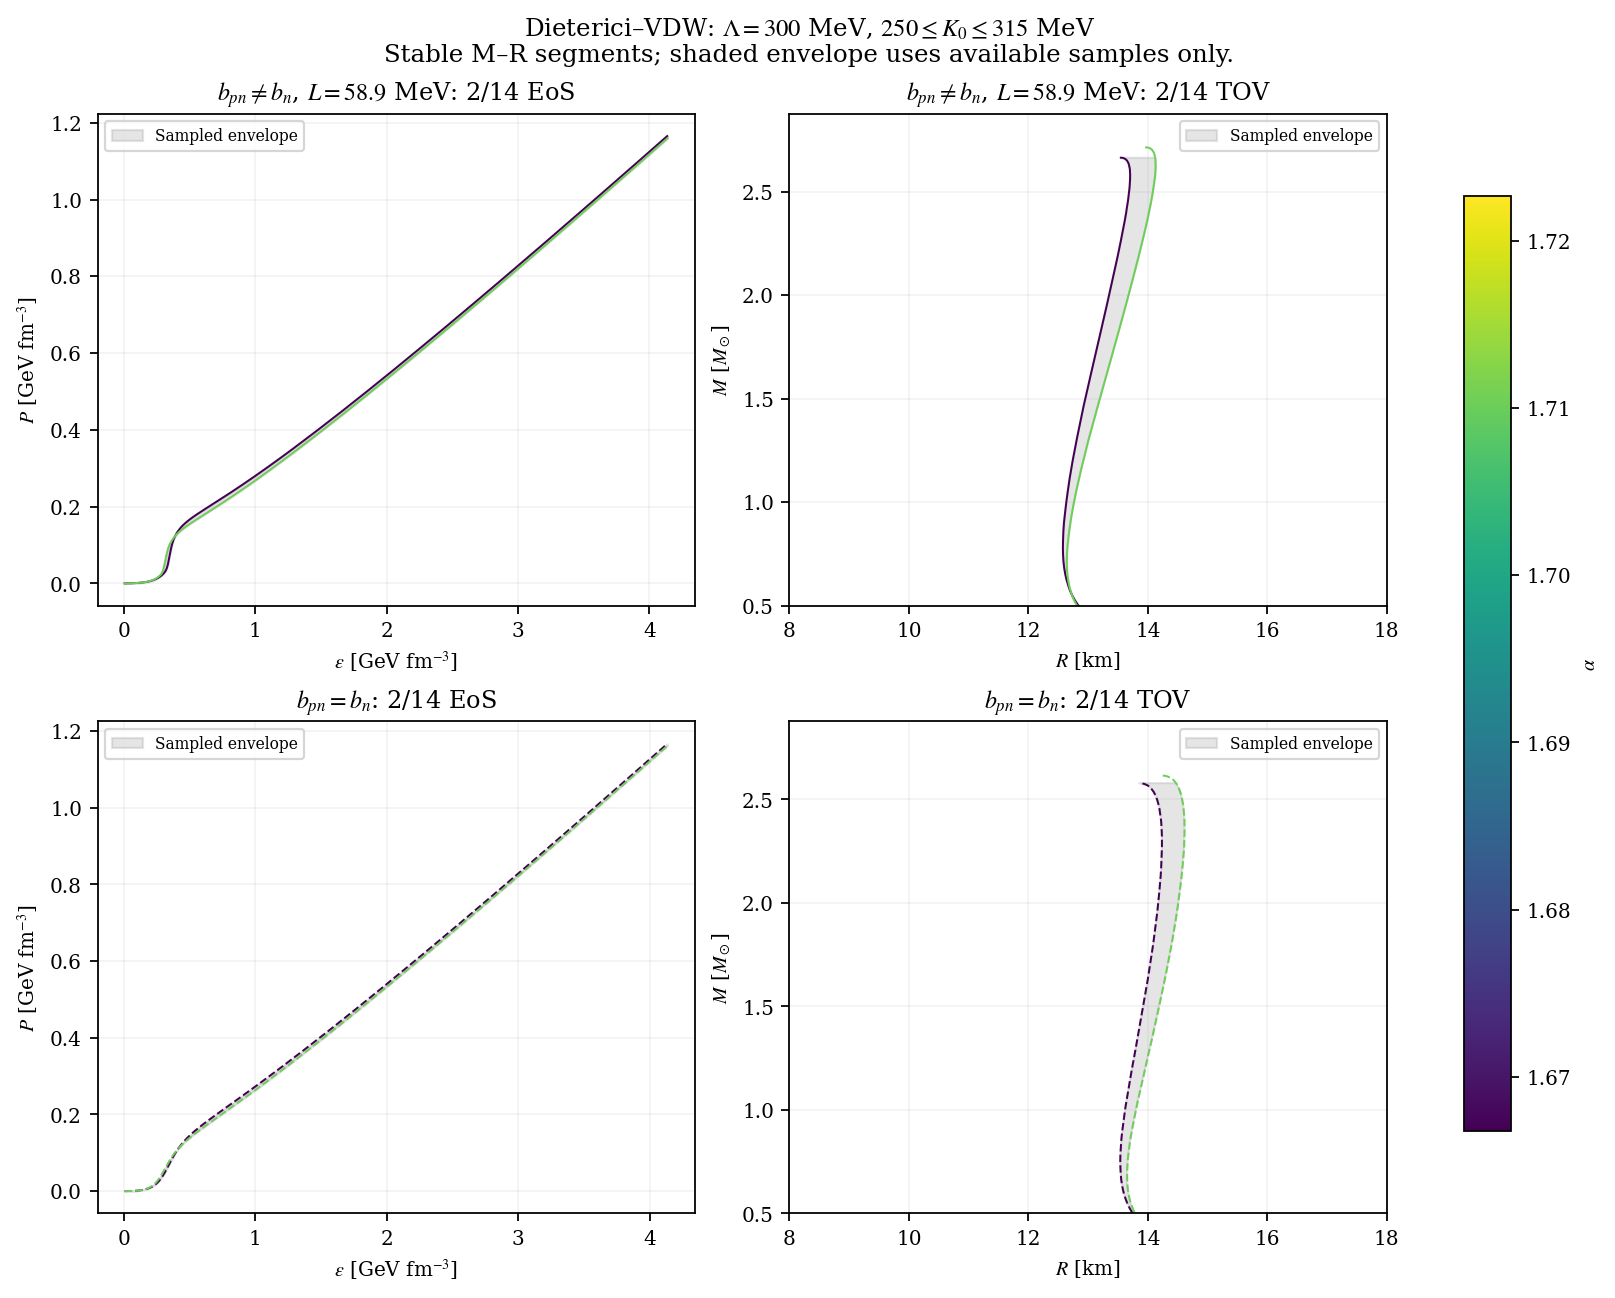

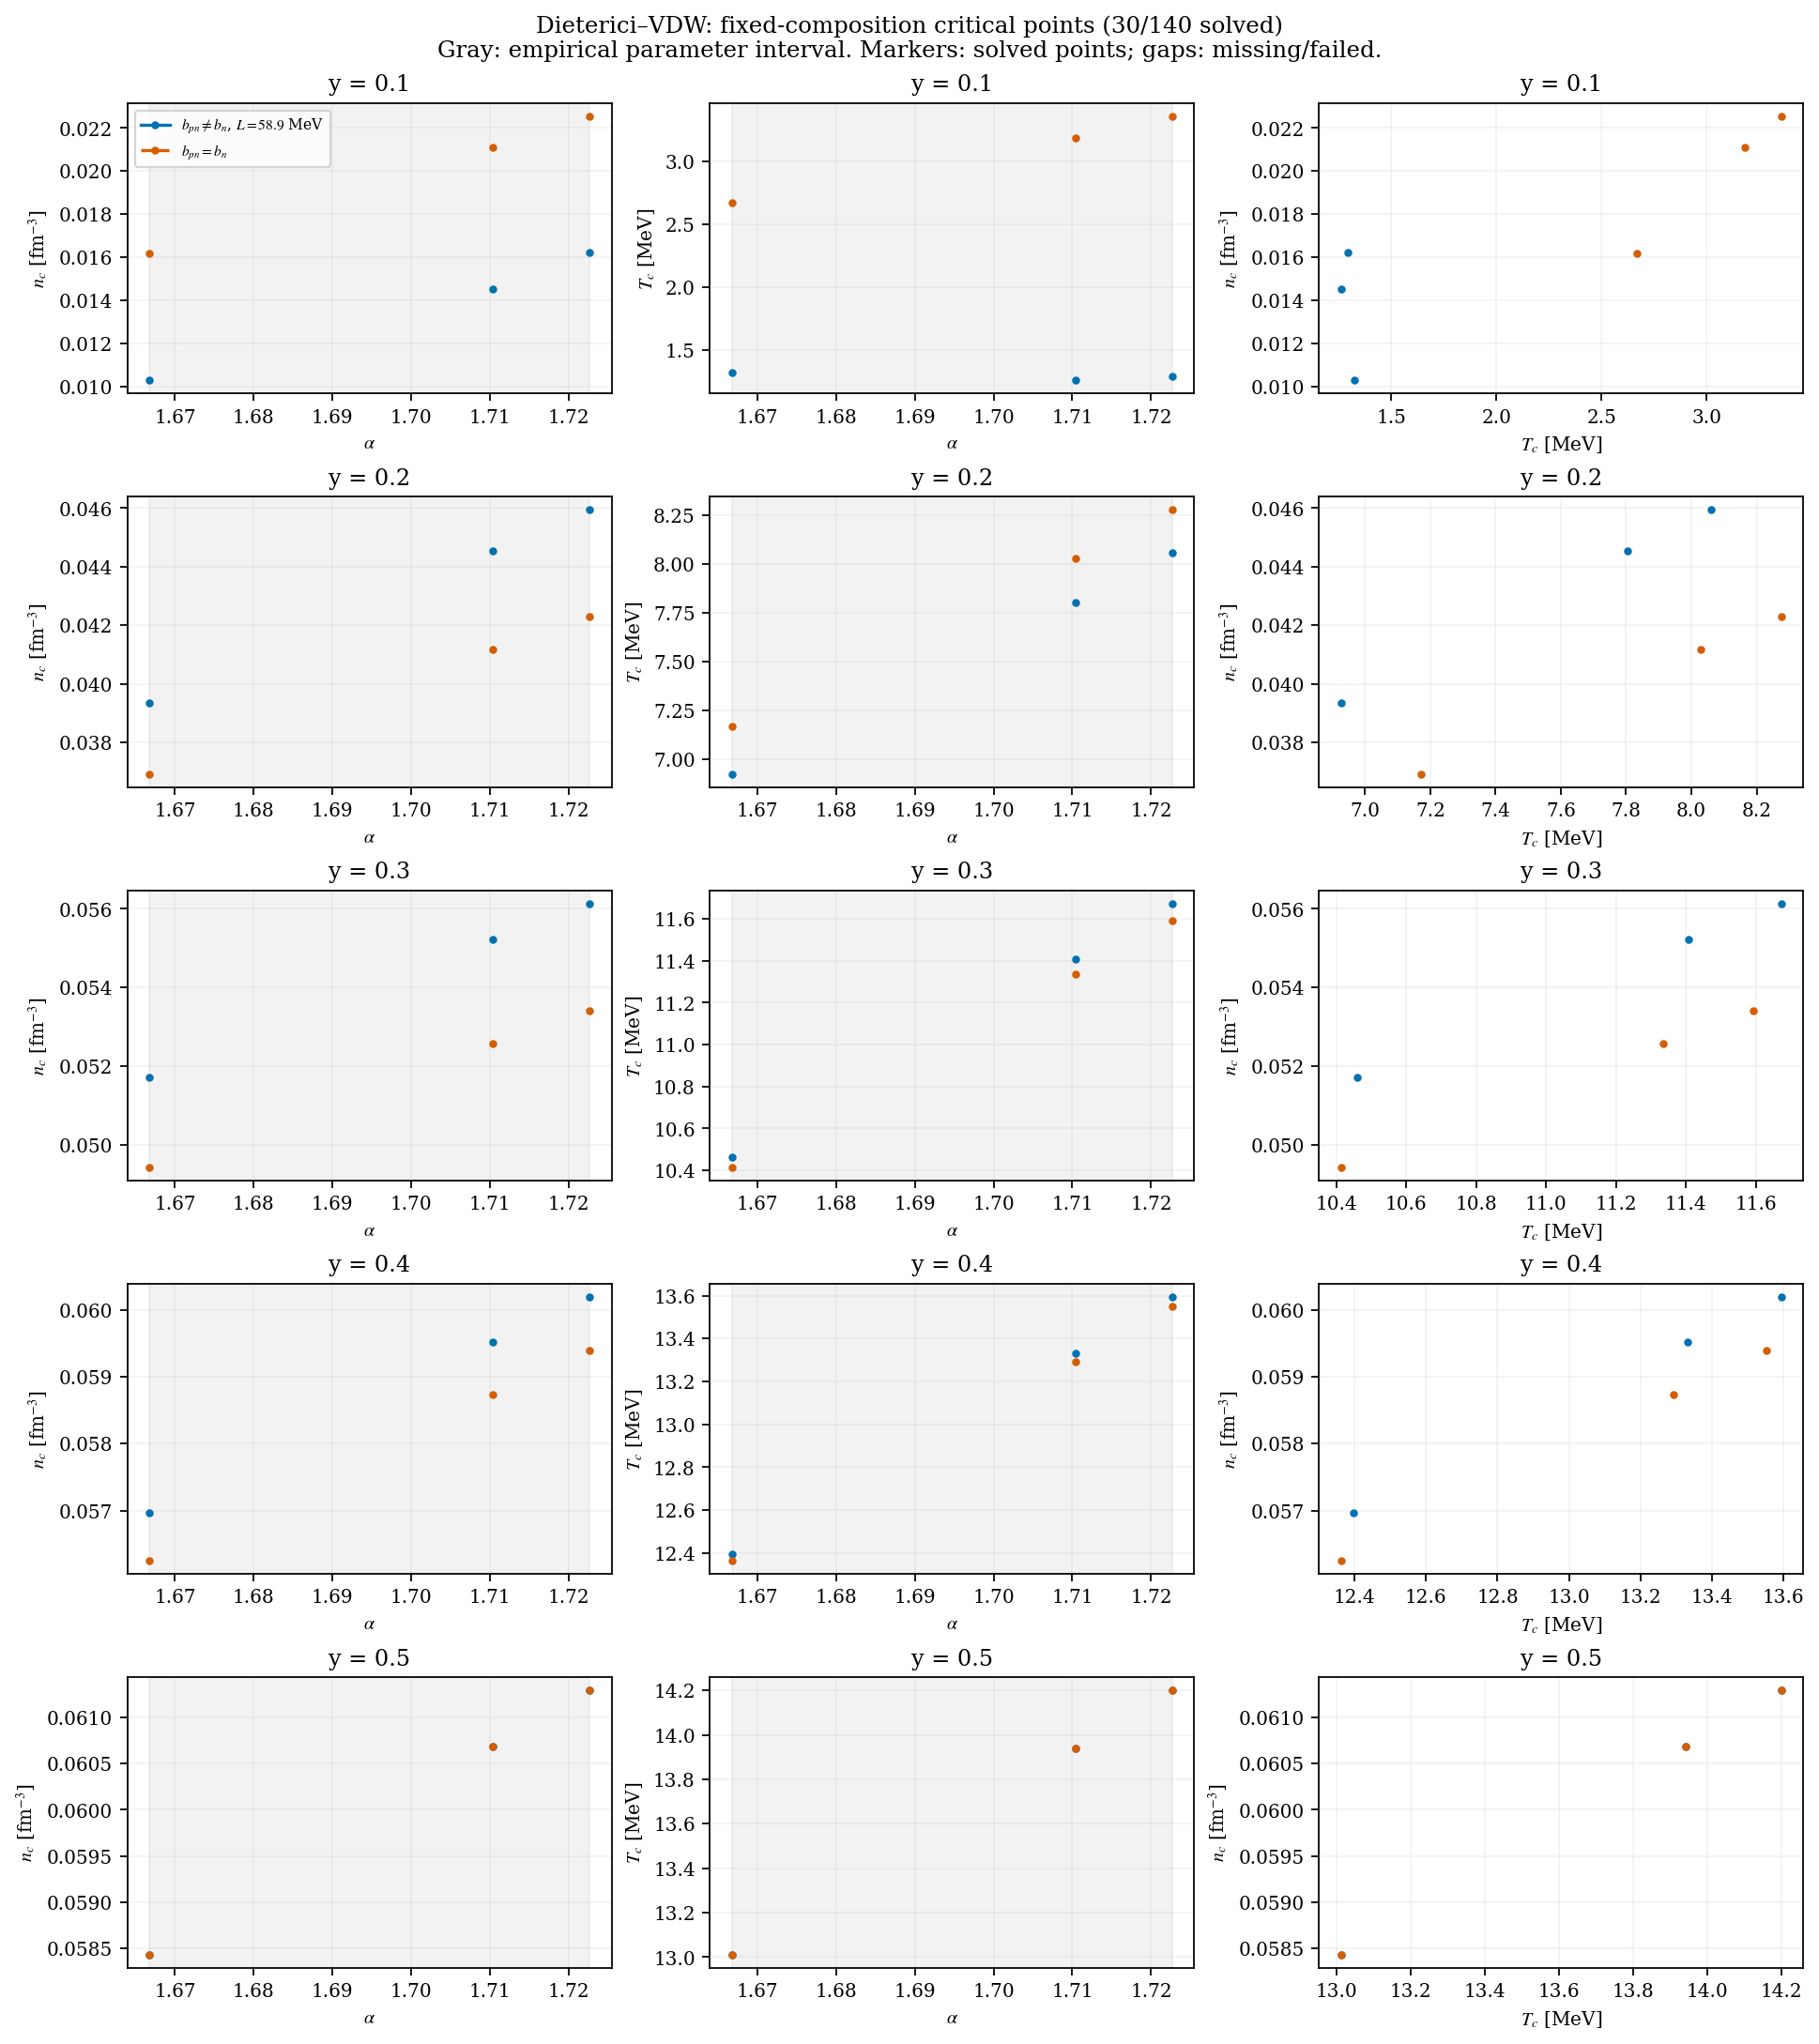

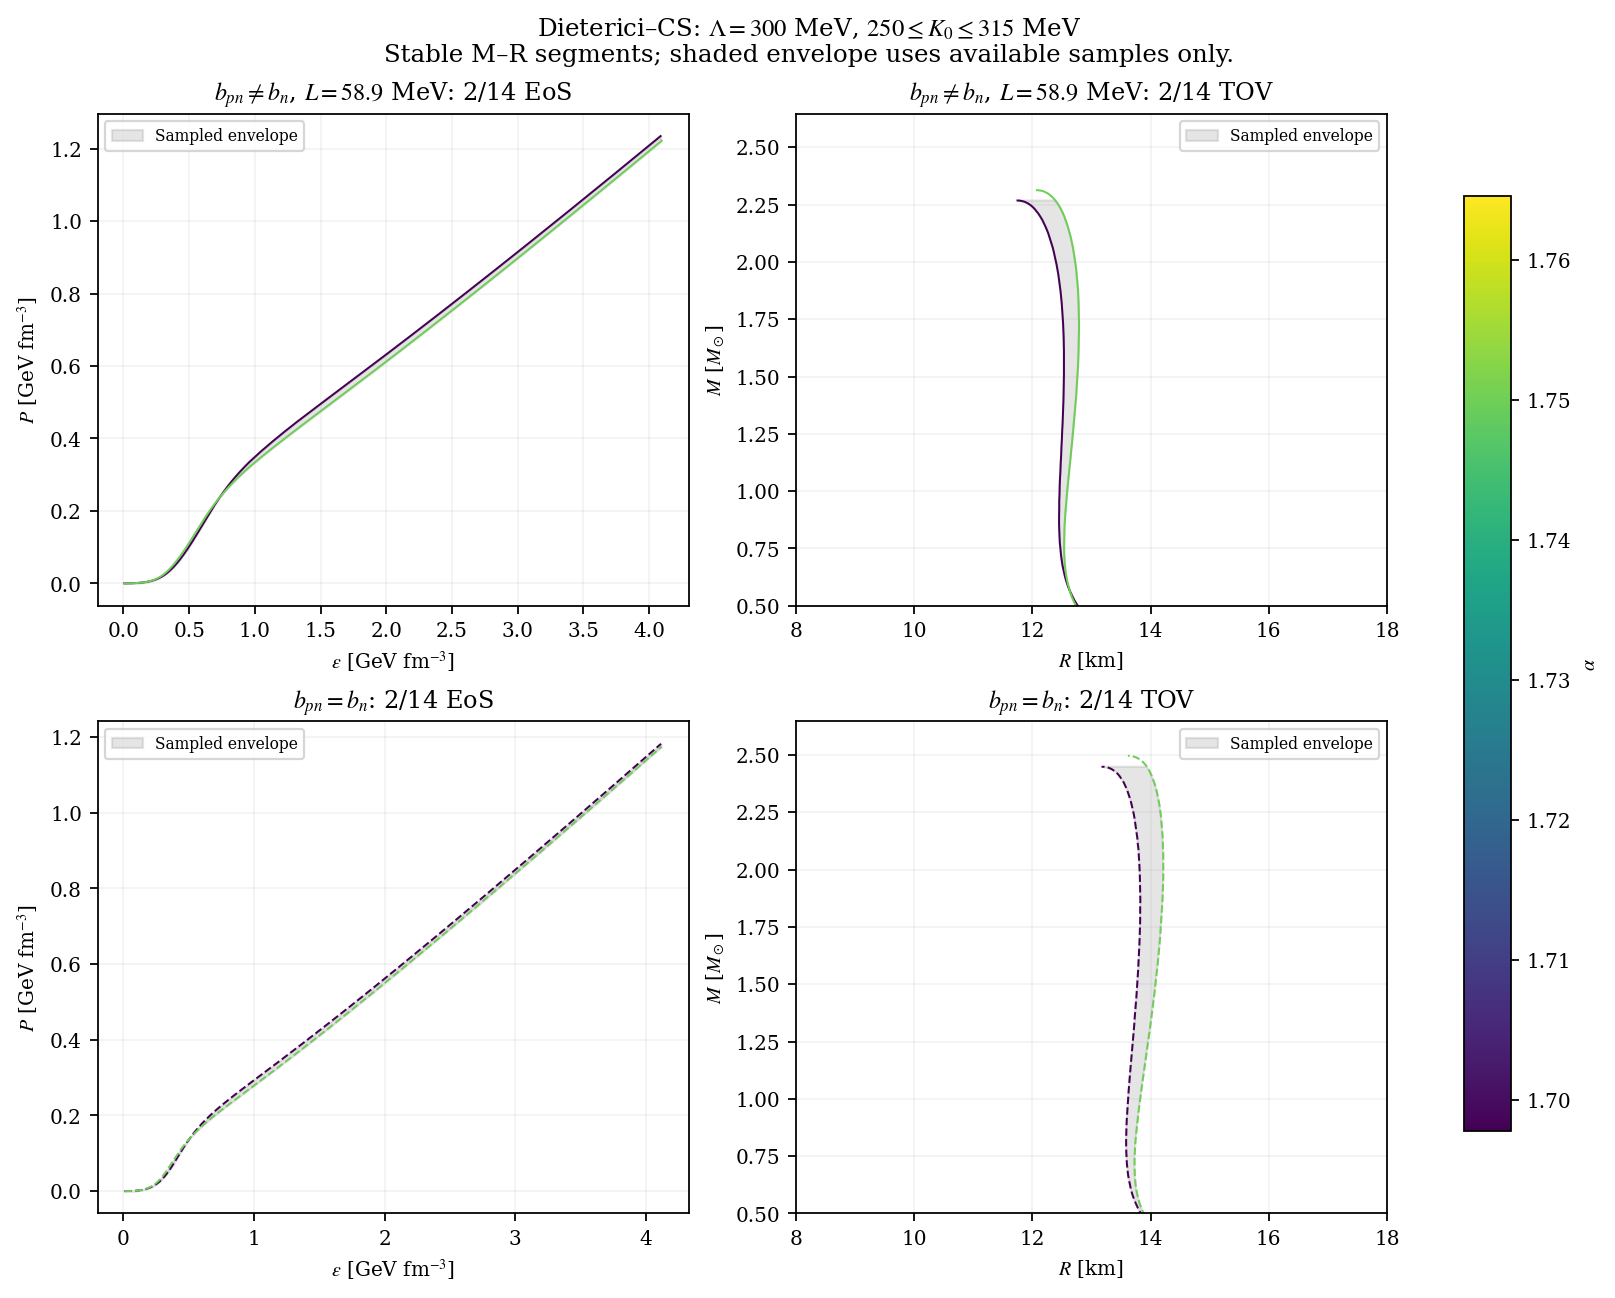

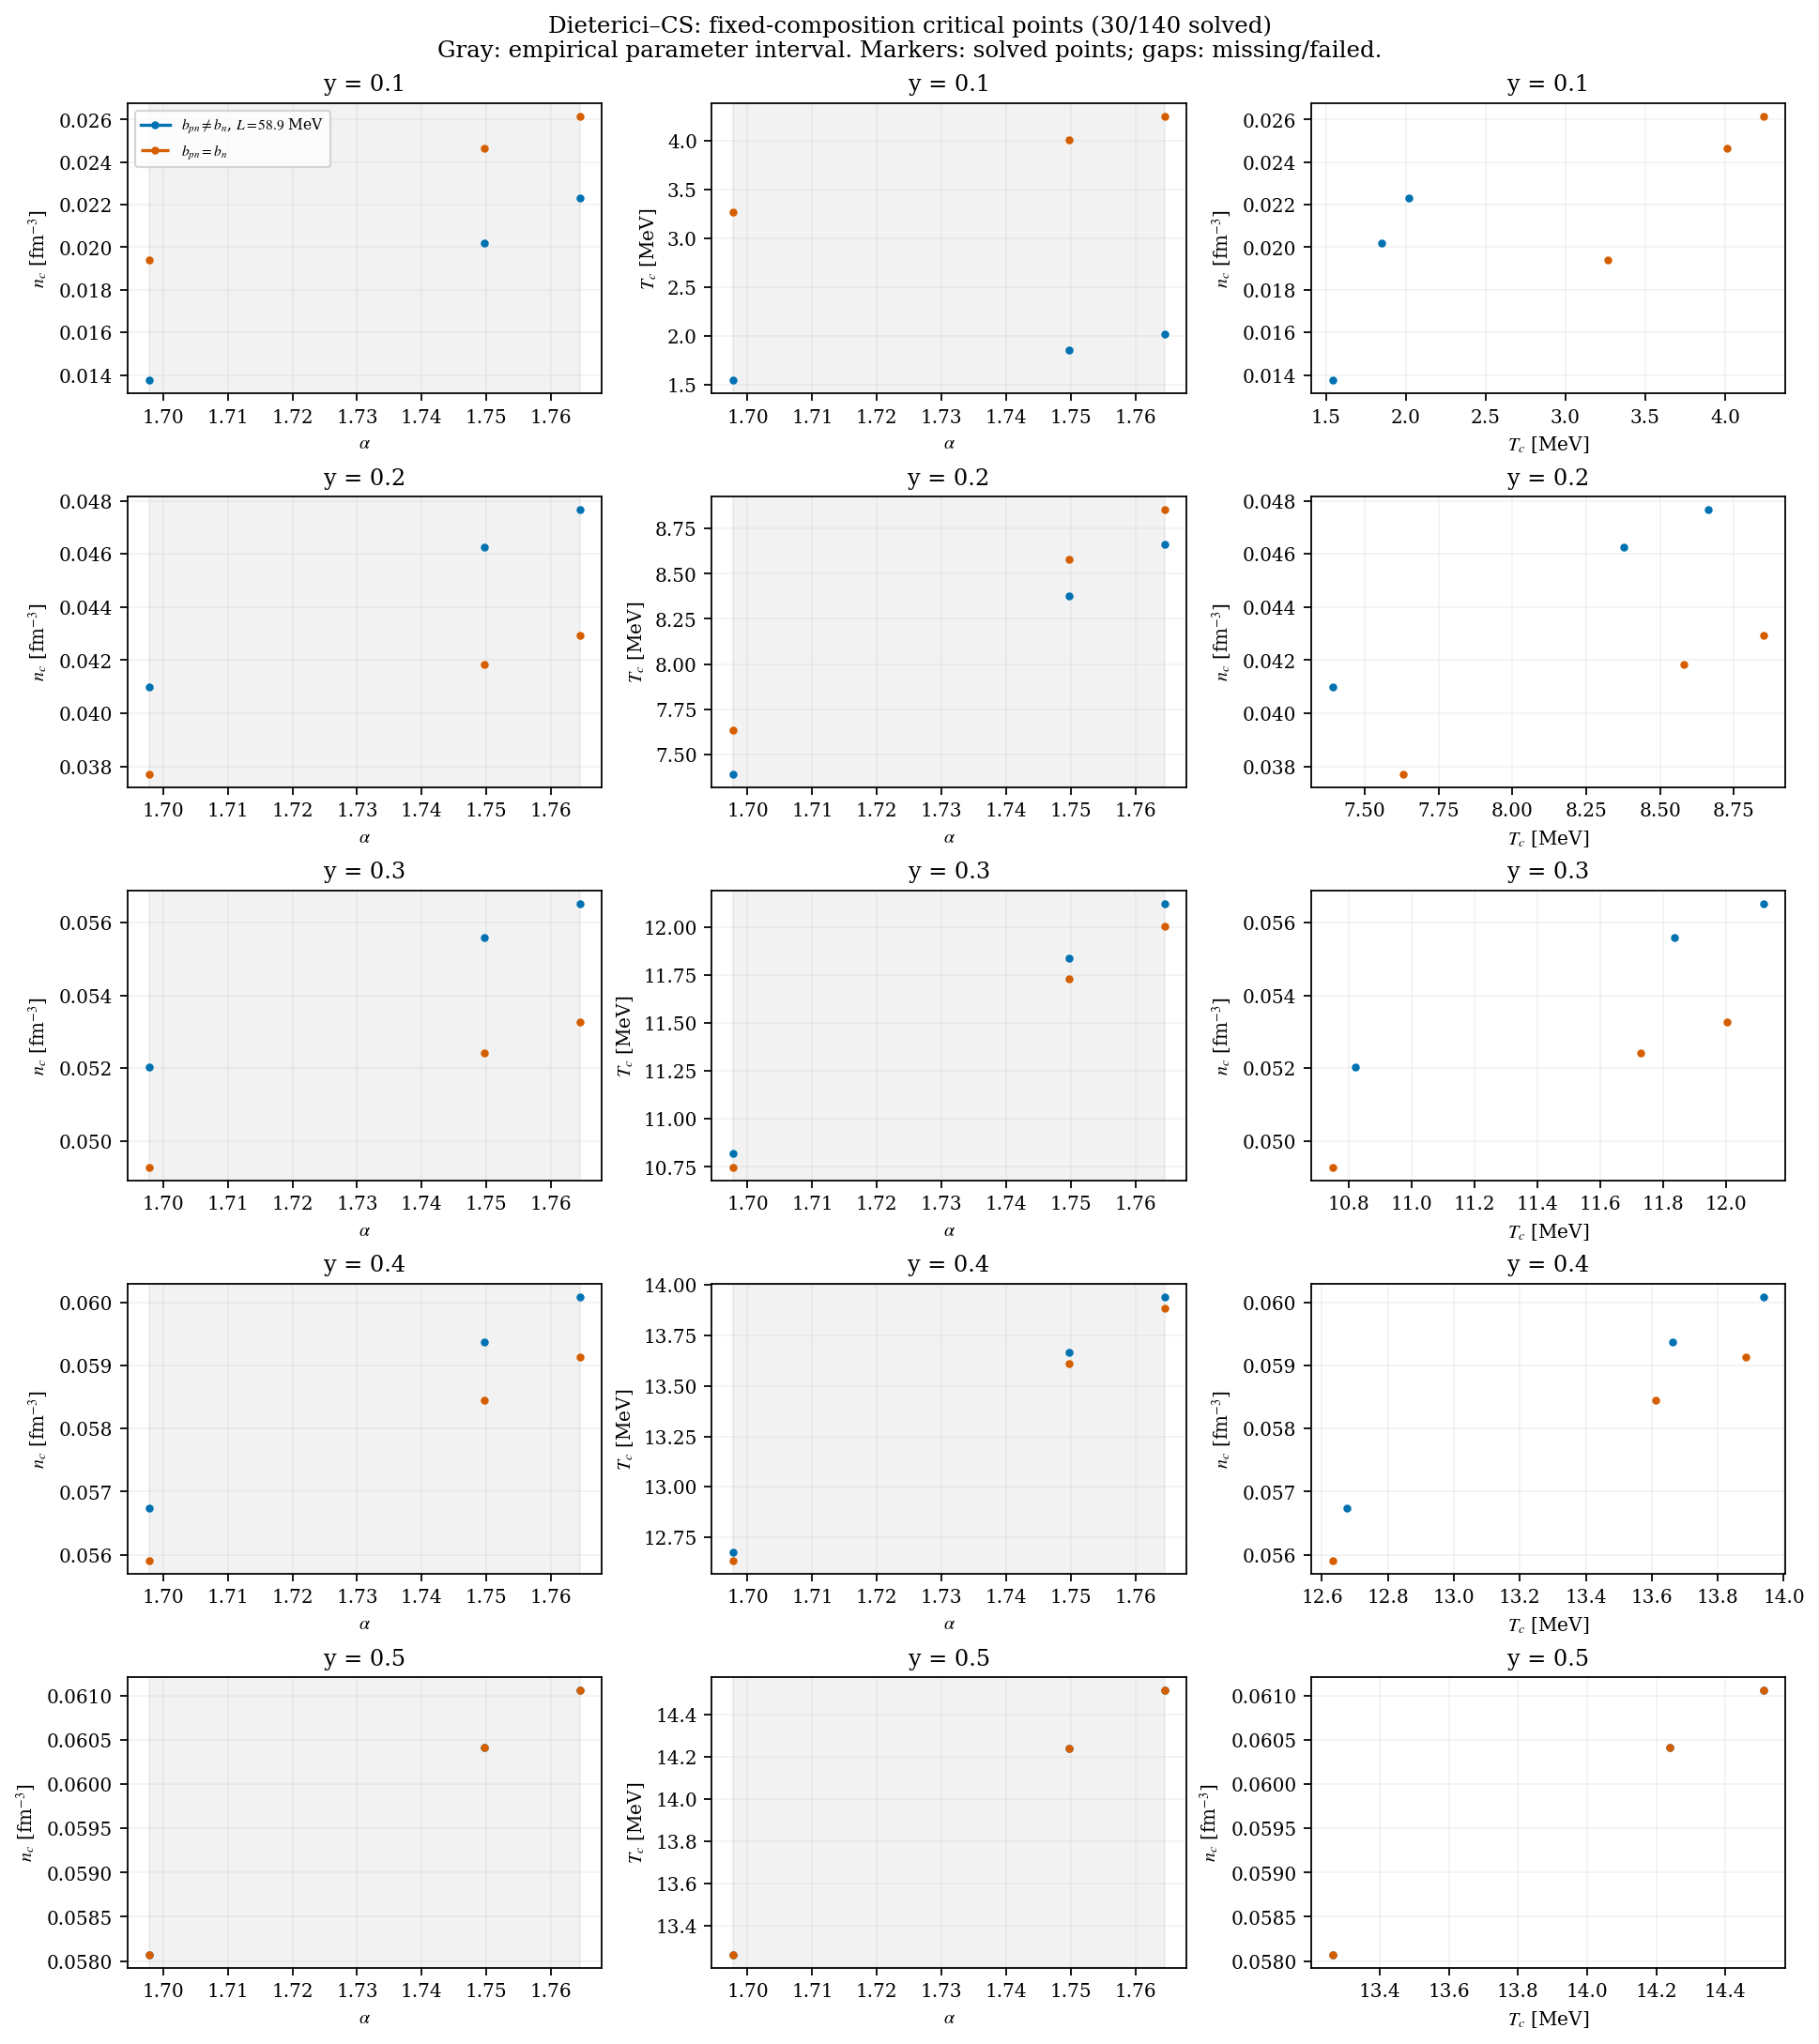

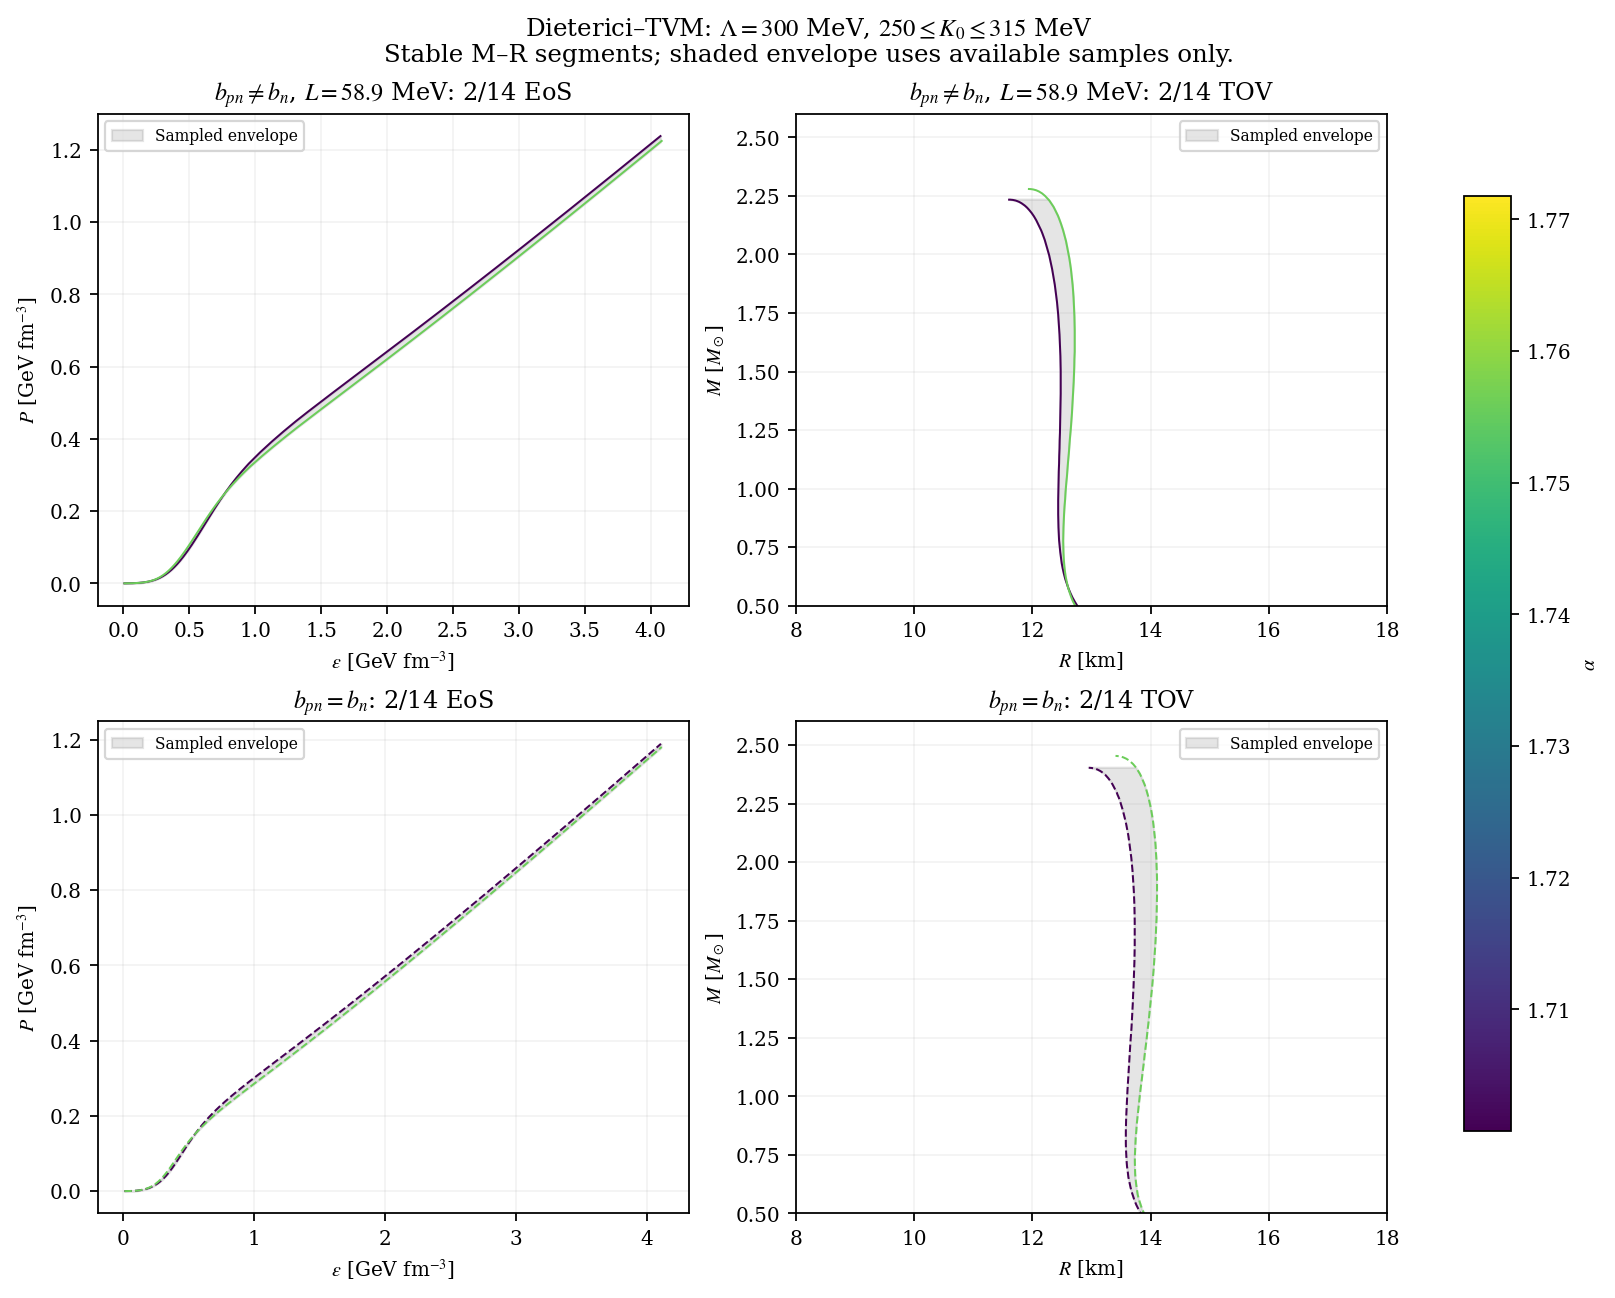

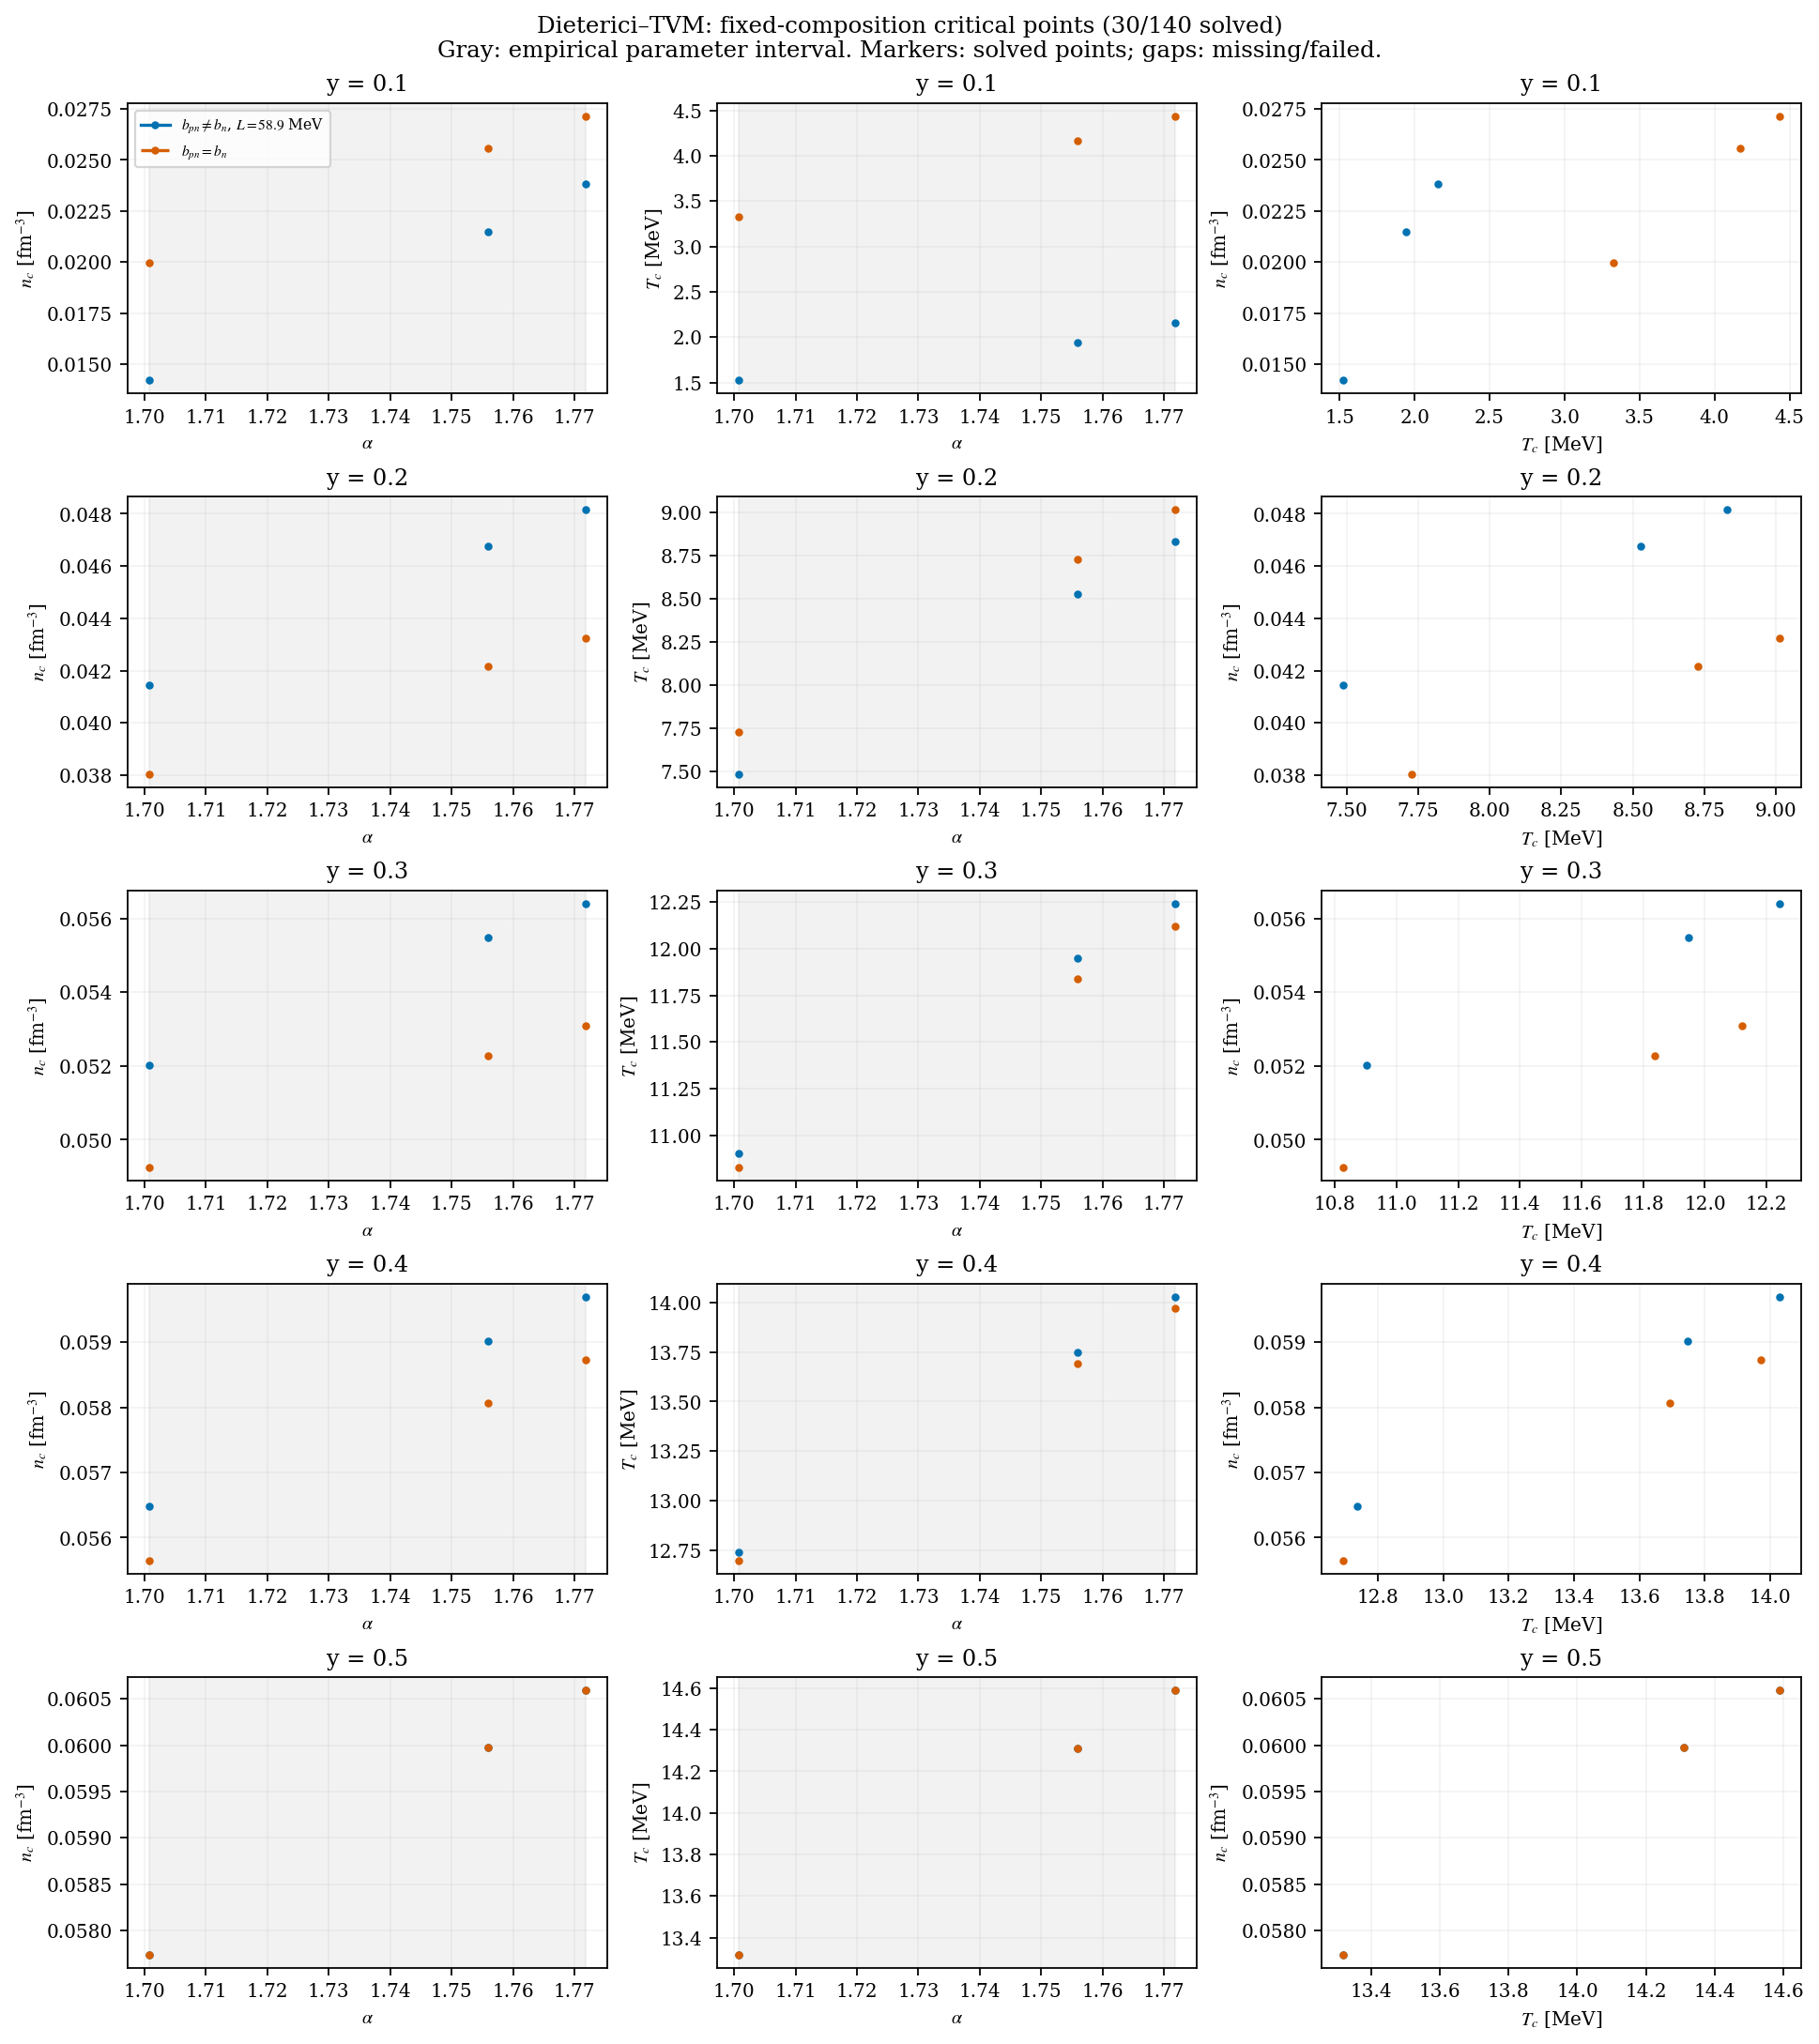

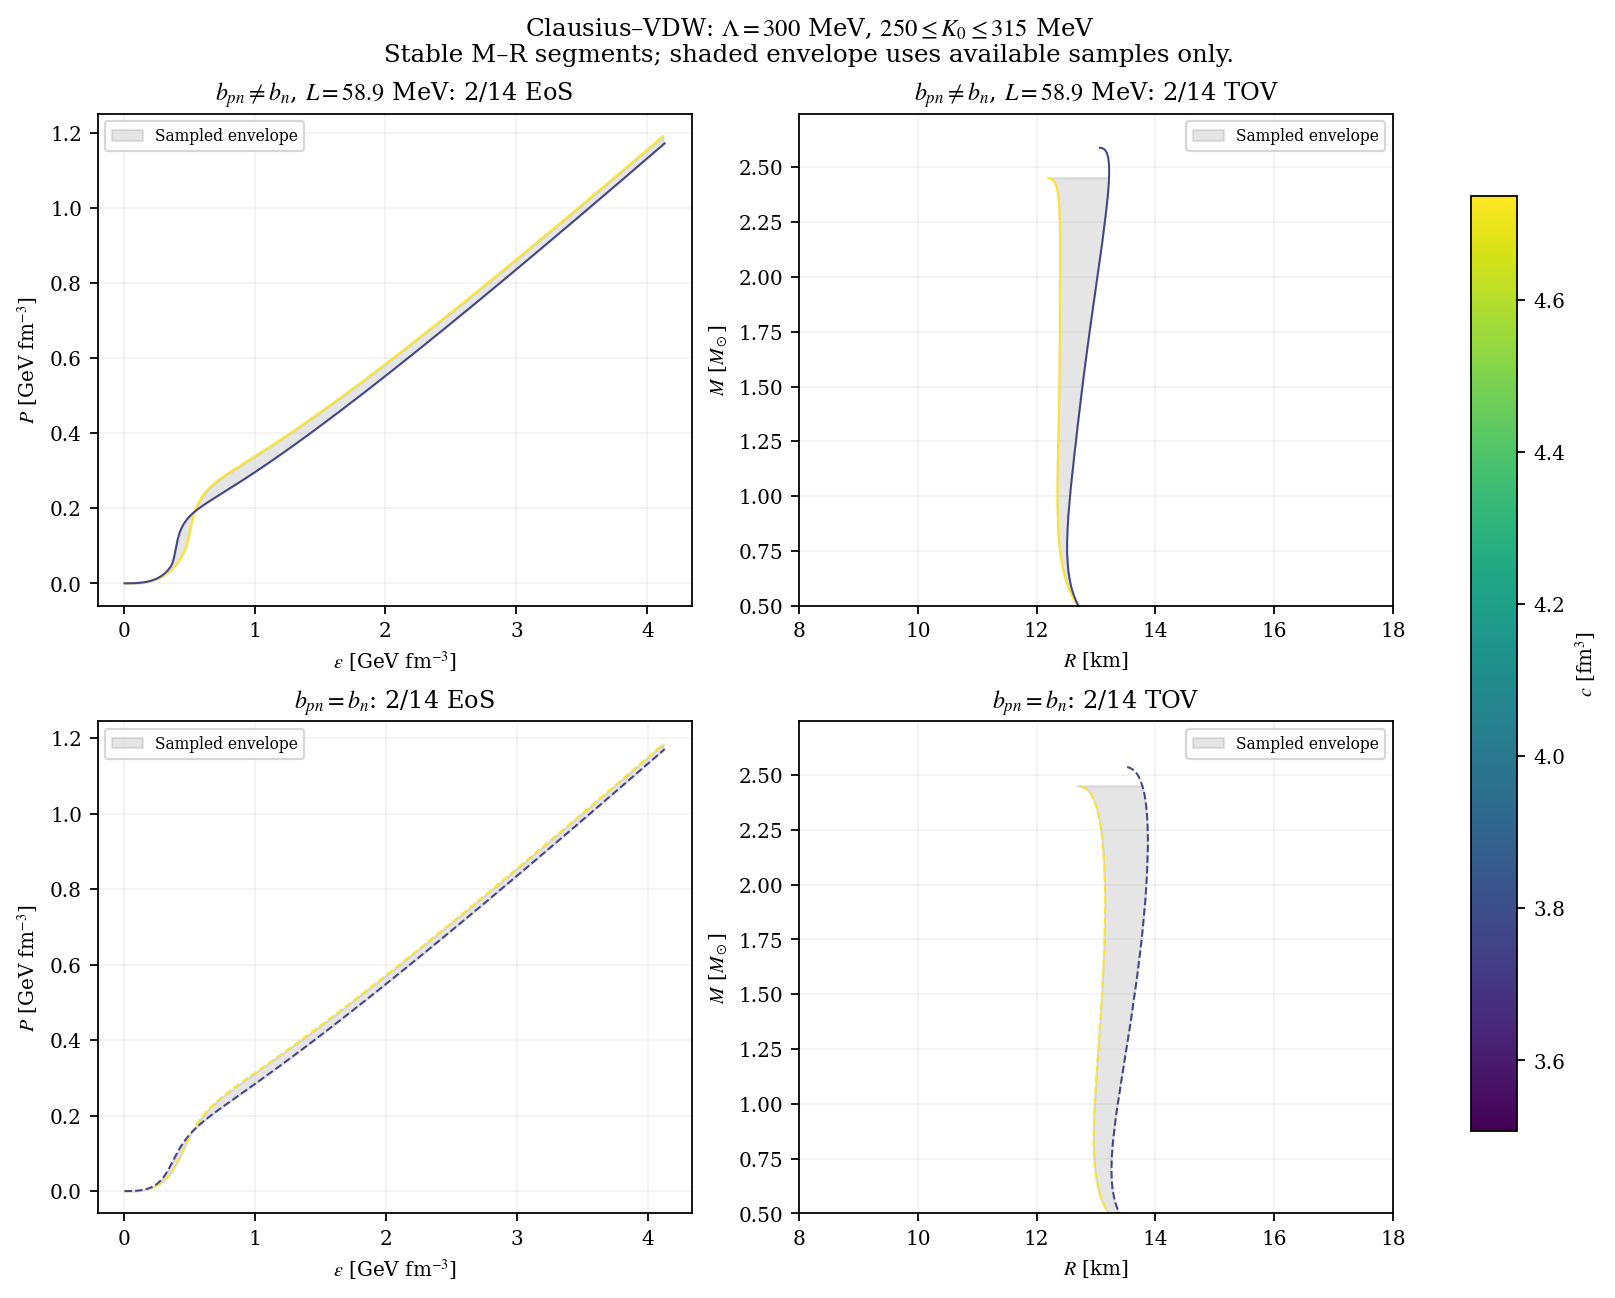

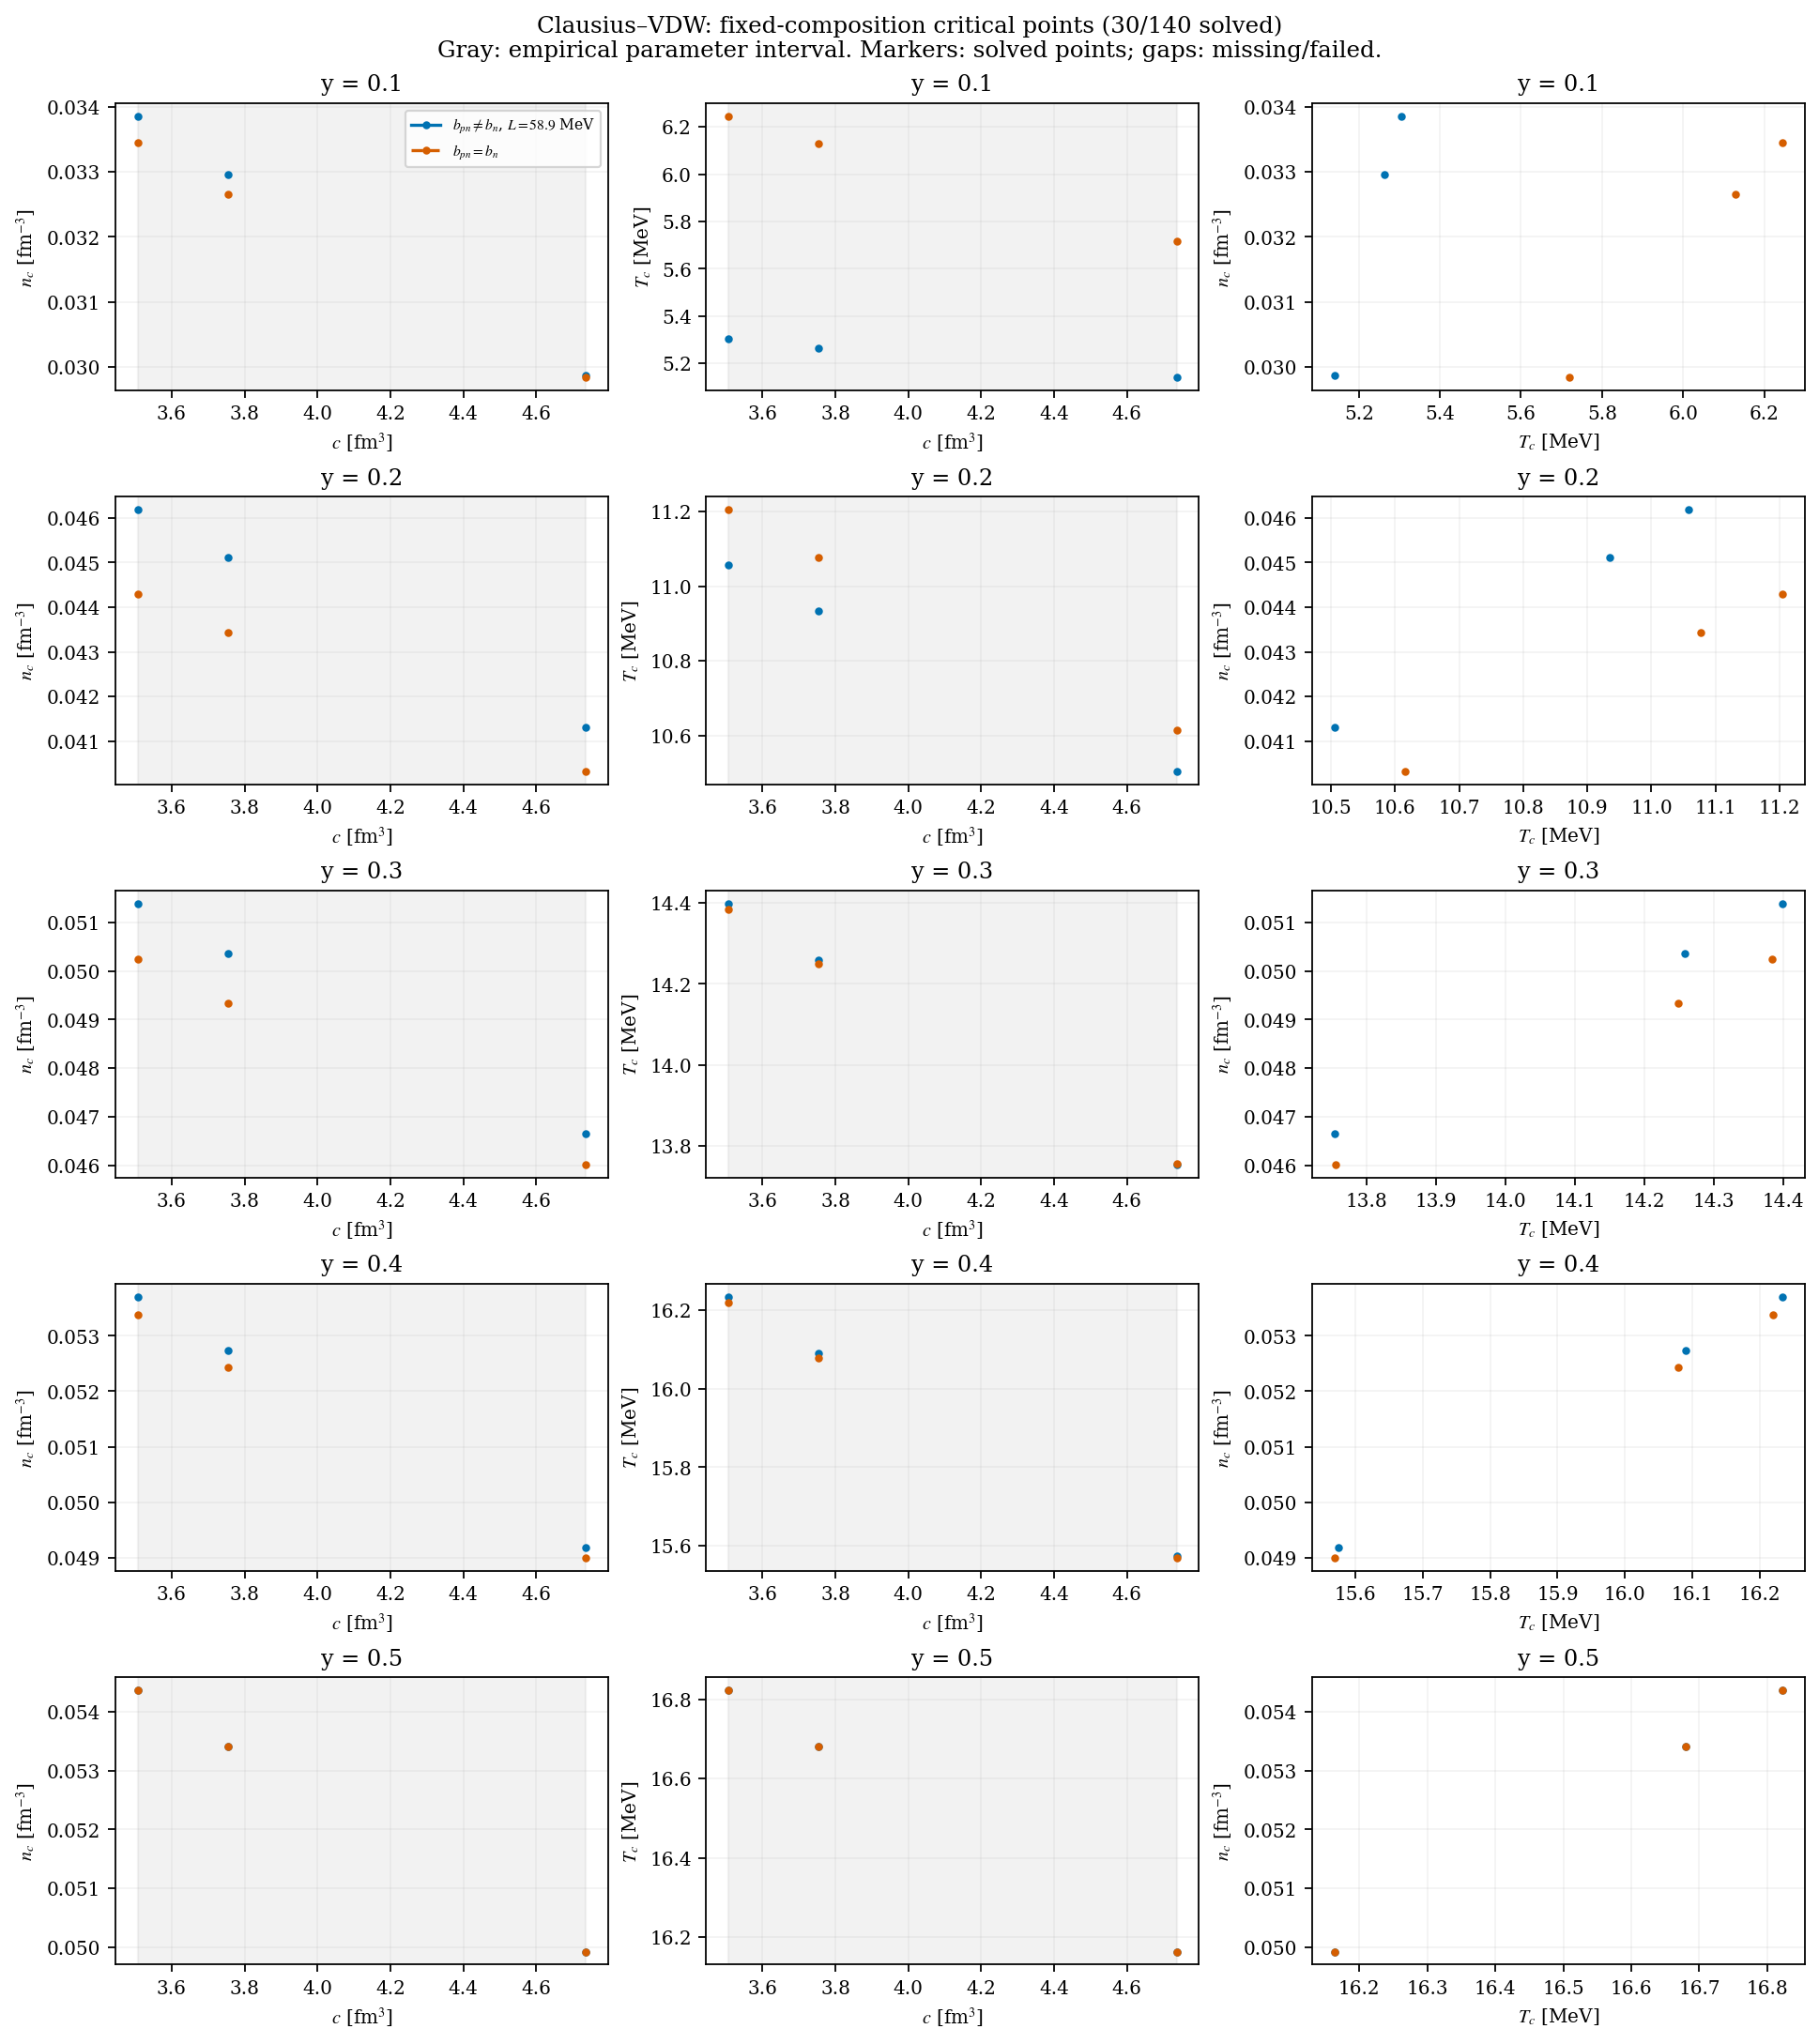

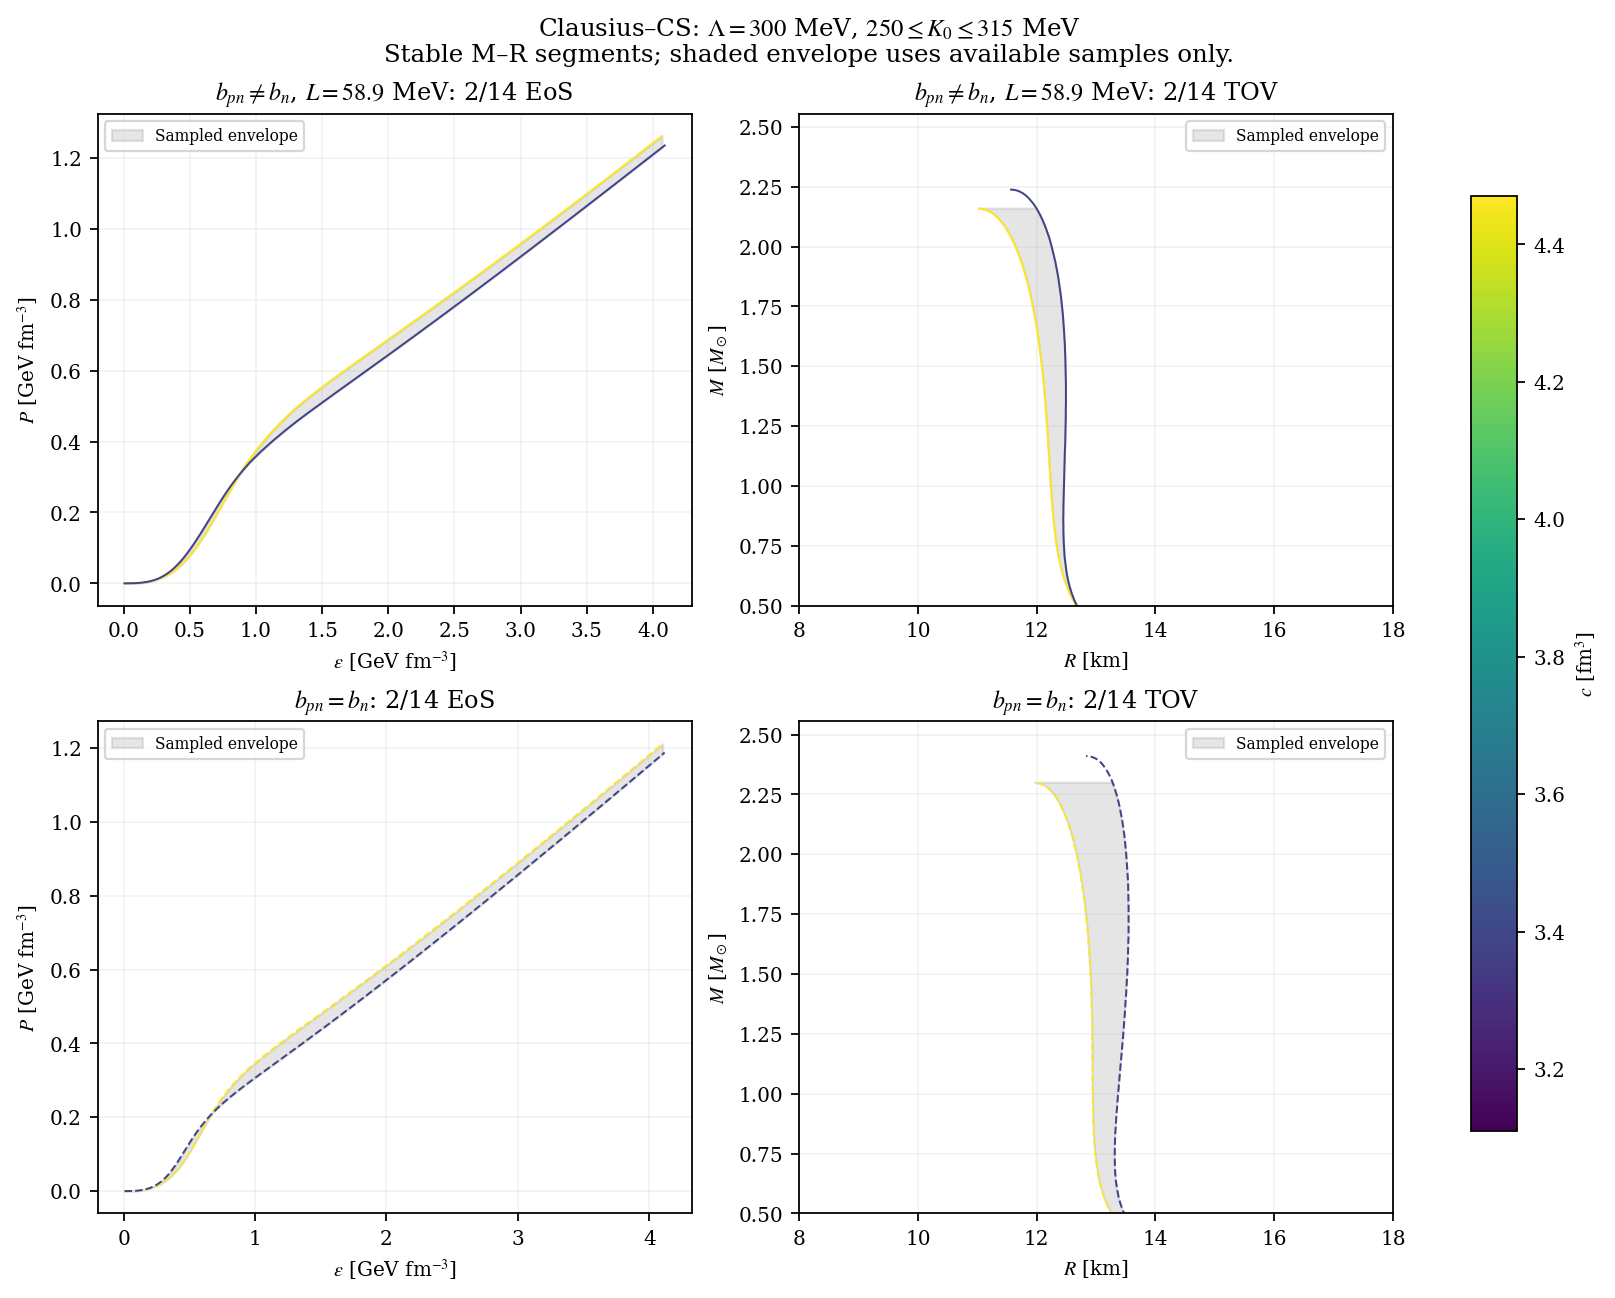

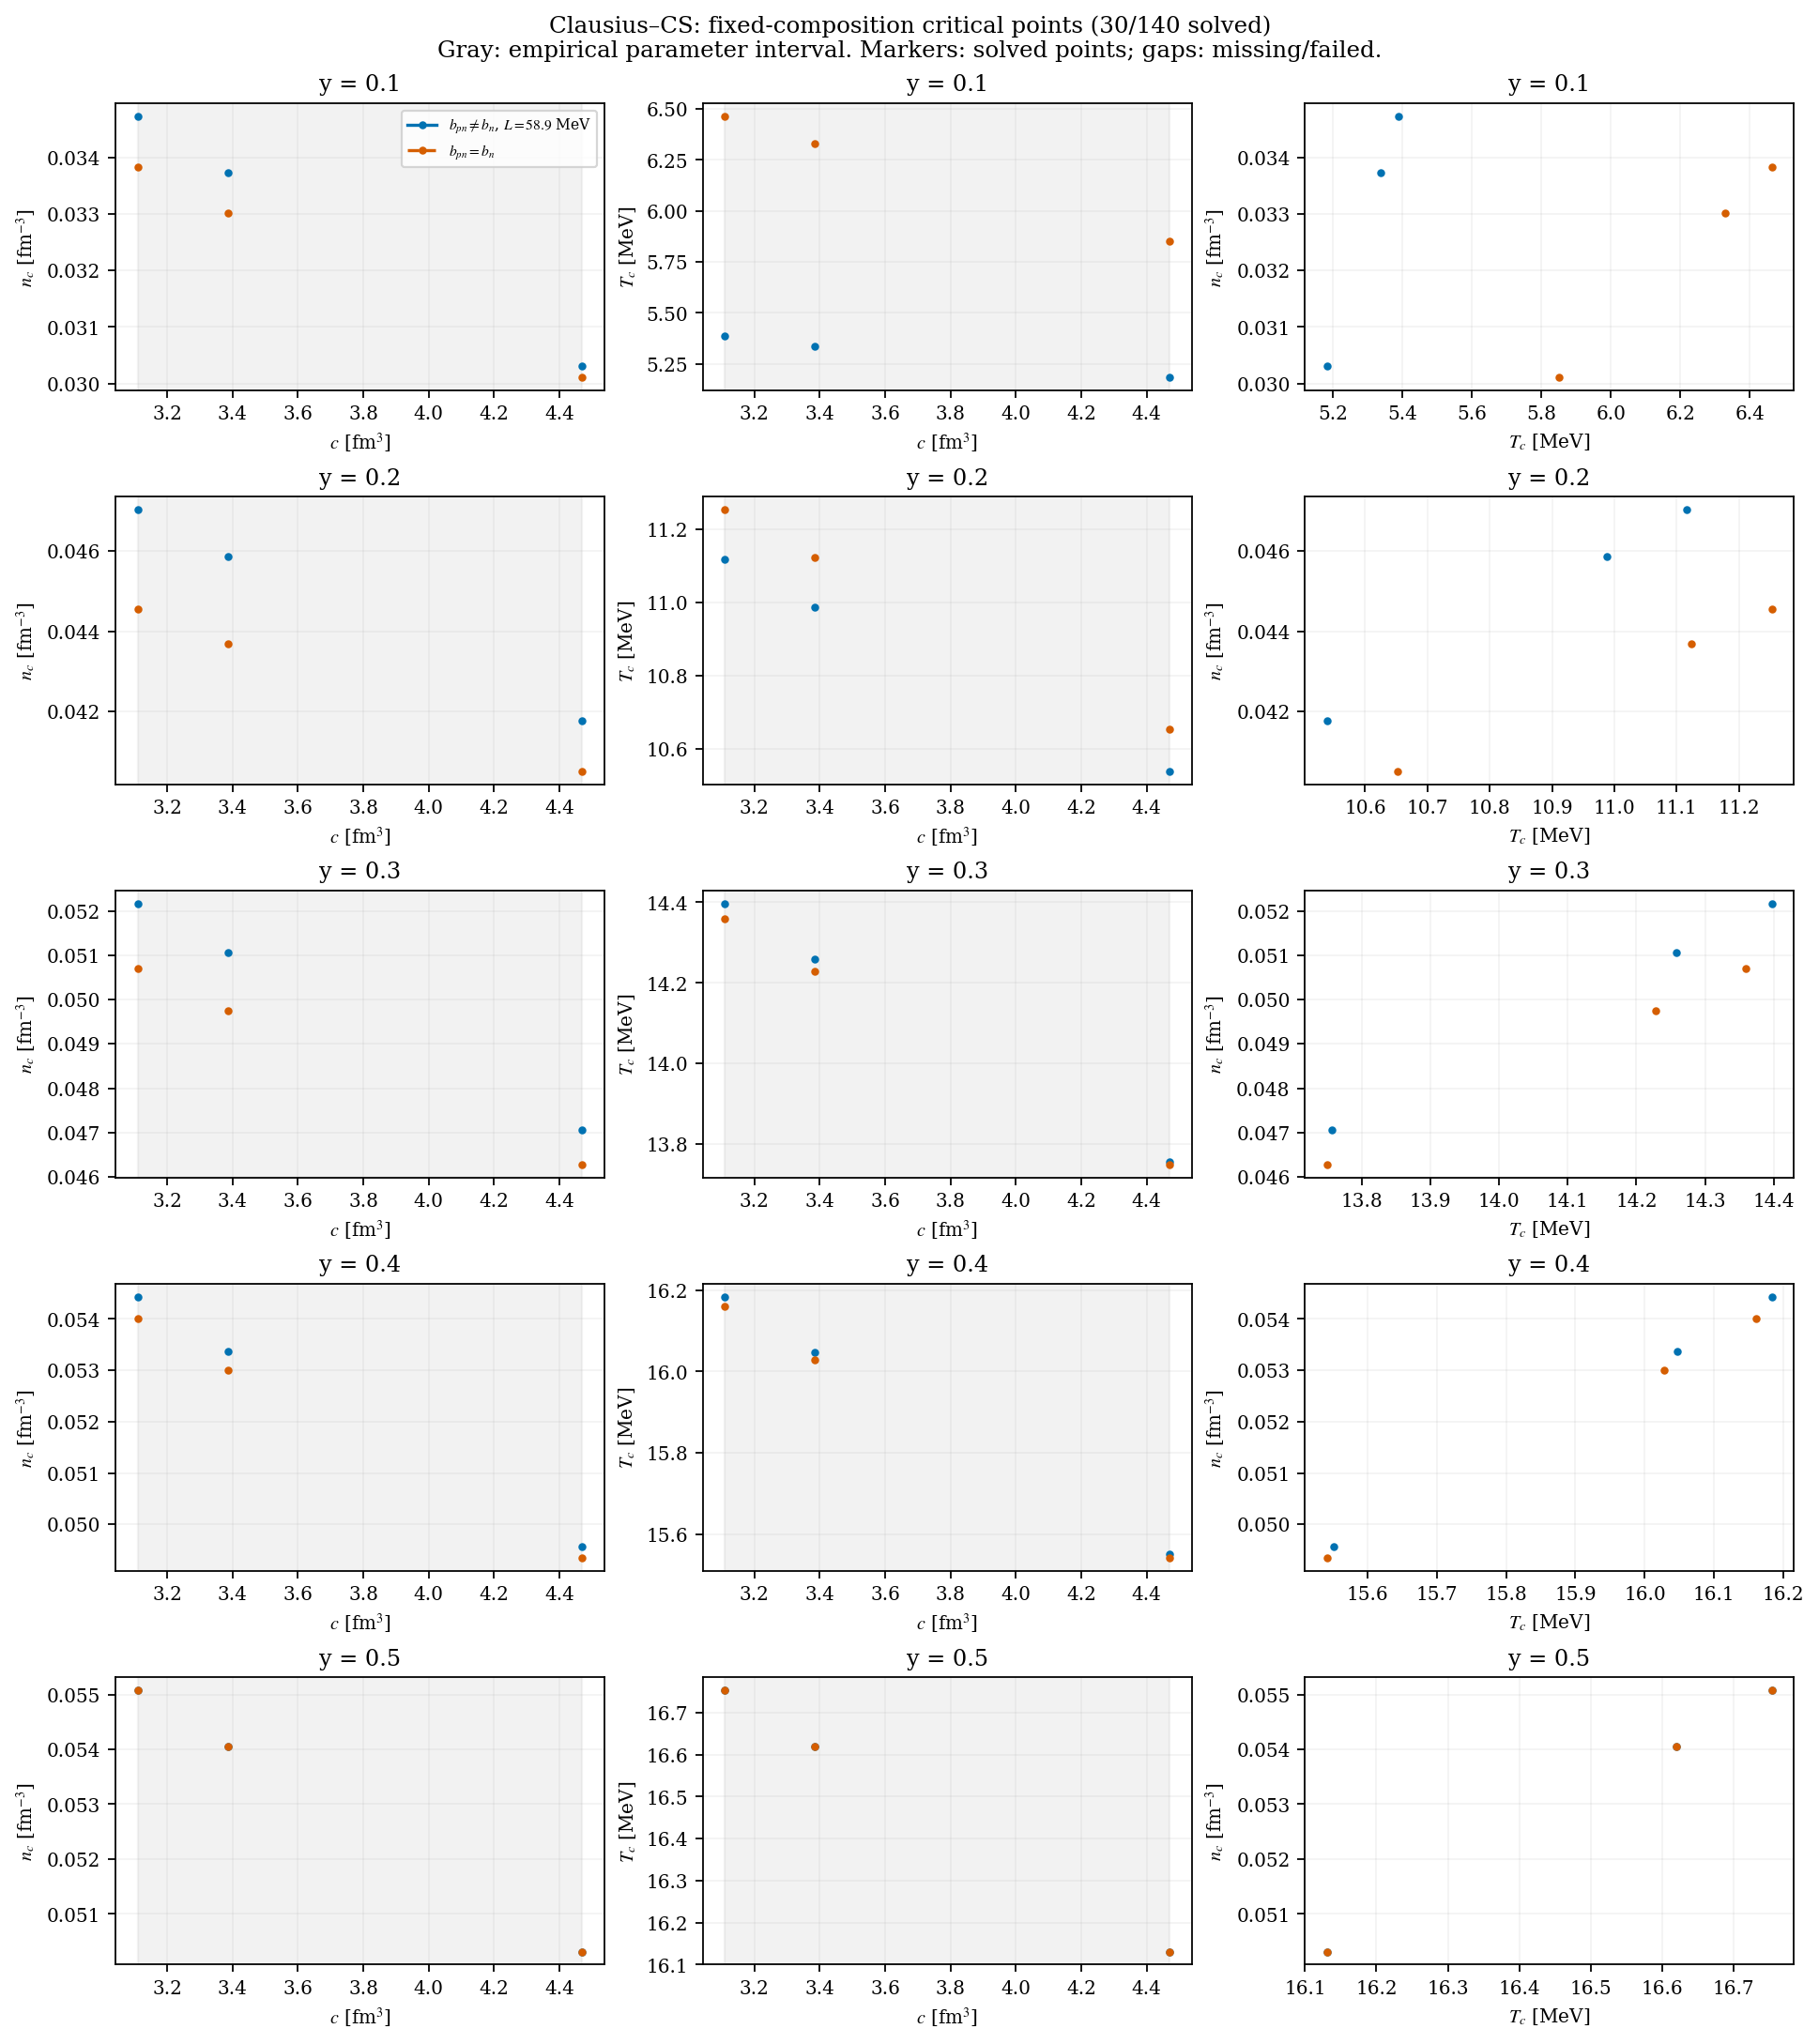

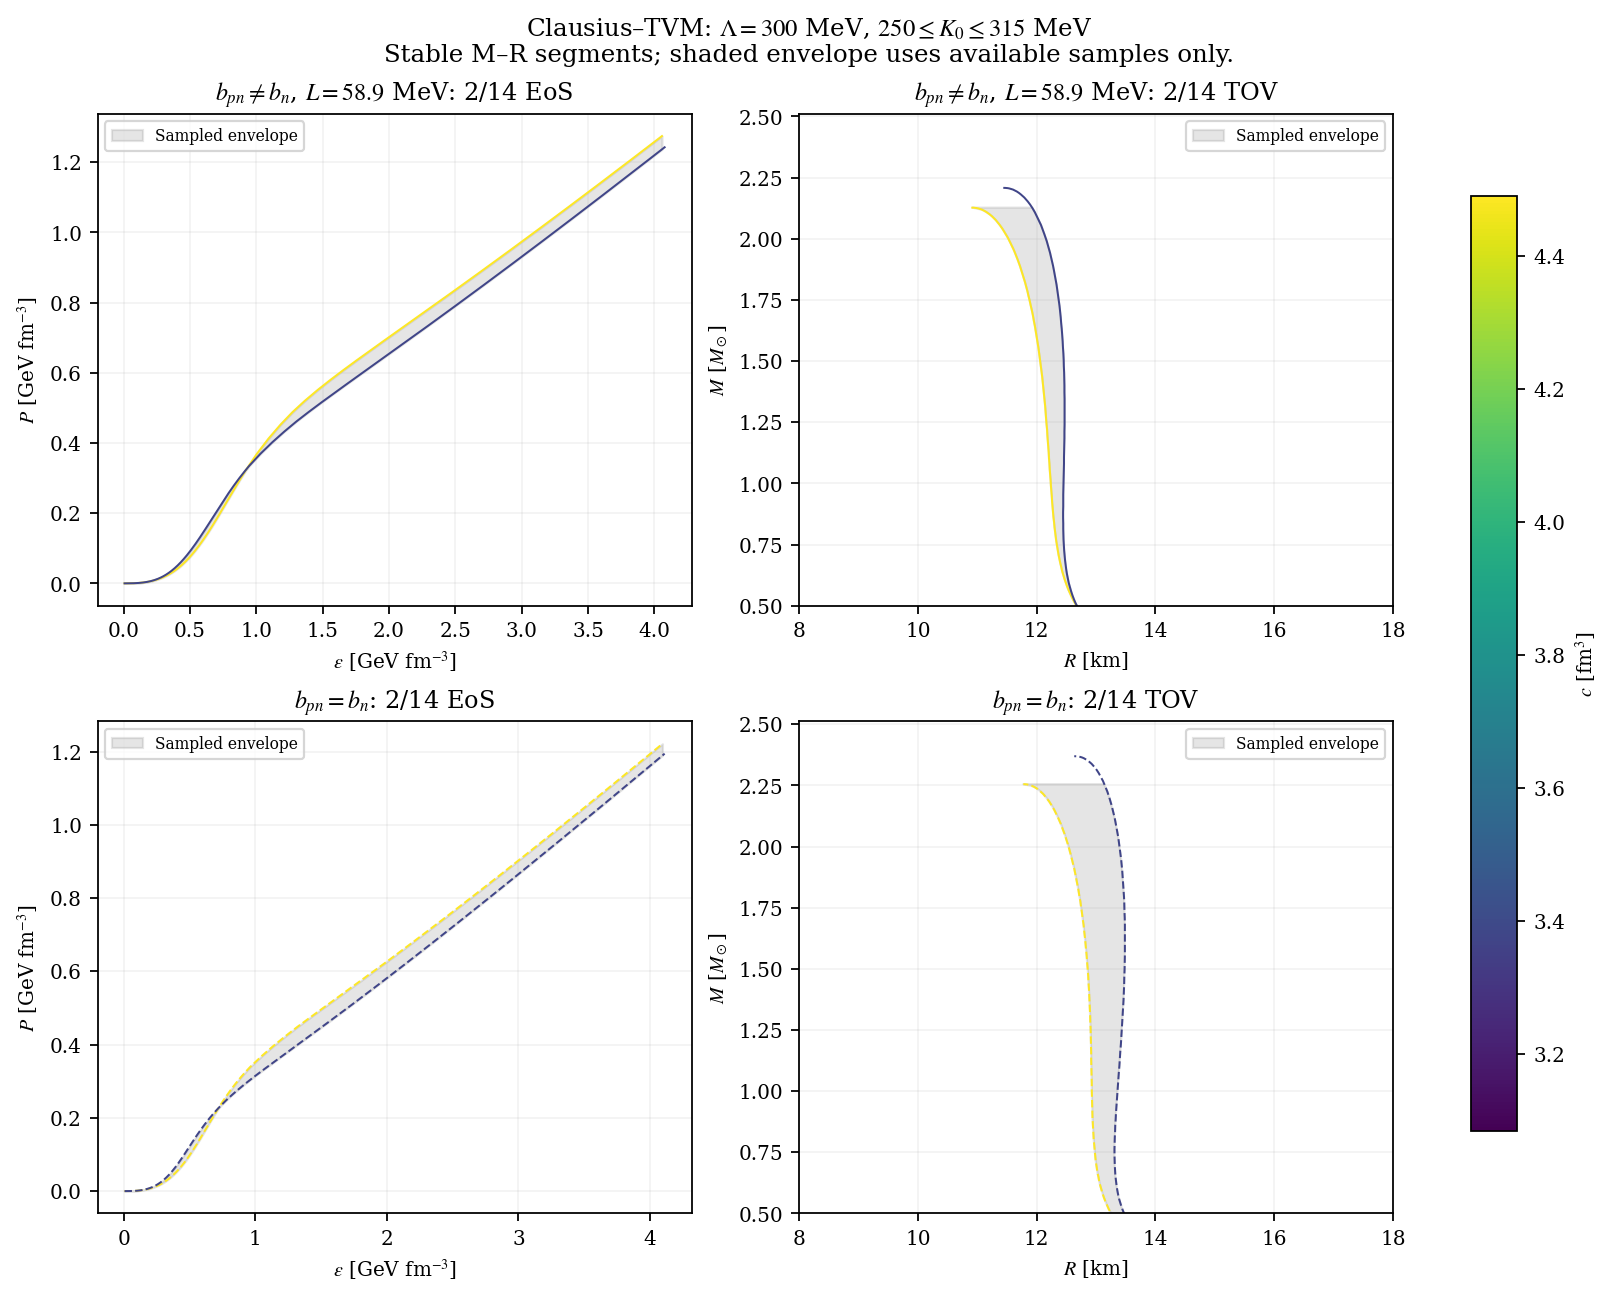

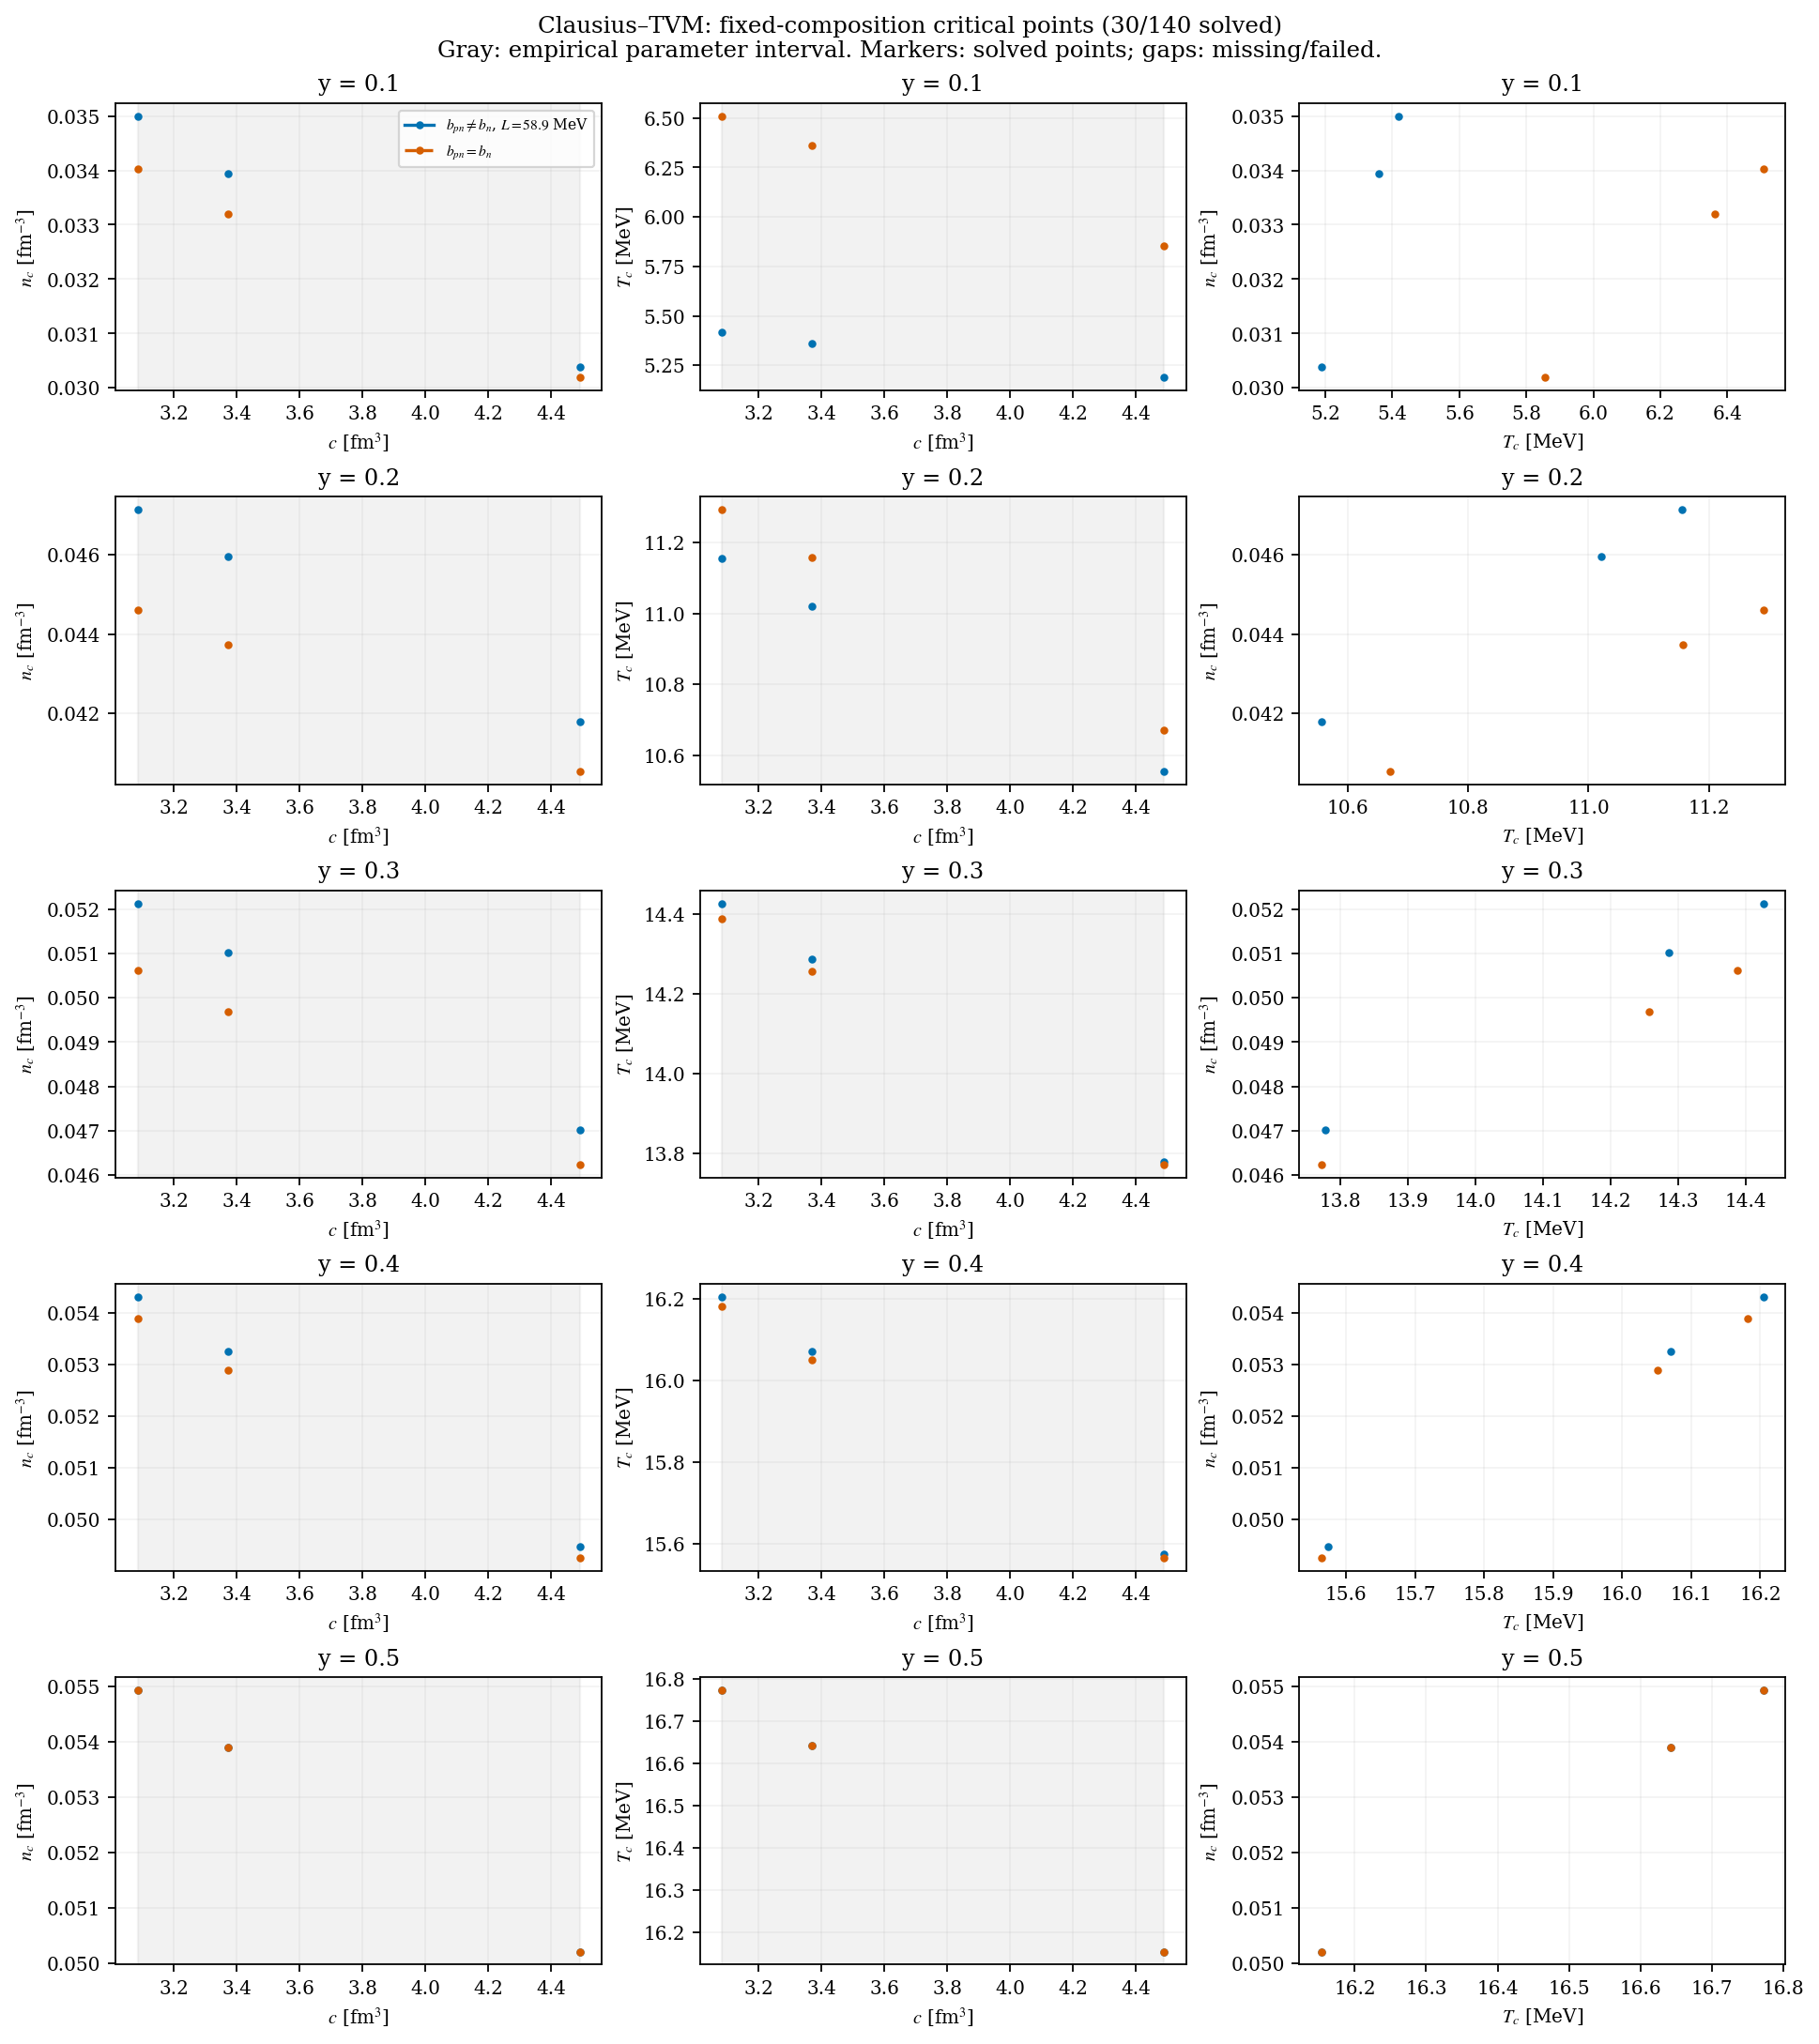

In [4]:
results, critical = suite.collect(K0_VALUES, MODELS, BRANCHES, CONTROLS)
figure_paths = plot_results(results, critical, K0_VALUES, CONTROLS)
for path in figure_paths:
    display(Image(filename=str(path)))
print('Figuras PNG/PDF/SVG:', suite.OUTPUT / 'figures')


In [5]:
show_coverage(results, critical)
complete = bool(results.fit_ok.all() and results.eos_ok.all()
                and results.tov_ok.all() and critical.status.eq('ok').all())
print('Malla completa:', complete)
print('EoS pendientes:', int((~results.eos_ok).sum()))
print('TOV pendientes:', int((~results.tov_ok).sum()))
print('Puntos críticos pendientes/fallidos:', int(critical.status.ne('ok').sum()))
display(results[['model_key', 'K0_MeV', 'branch_mode', 'parameter_value',
    'b_n', 'b_pn', 'J', 'L', 'maximum_mass_msun',
    'radius_at_maximum_mass_km', 'maximum_vs2', 'maximum_at_eos_boundary',
    'integration_warning_count']])
good = critical[critical.status.eq('ok')]
if not good.empty:
    print('Máximo |dP/dn|:', good.dPdn.abs().max())
    print('Máximo |d²P/dn²|:', good.d2Pdn2.abs().max())
    symmetric = good[np.isclose(good.y, 0.5)].pivot_table(
        index=['model_key', 'K0_MeV'], columns='branch_mode', values=['Tc_MeV','nc_fm3'])
    if all(branch in symmetric.columns.get_level_values(1) for branch in BRANCHES):
        for field in ['Tc_MeV','nc_fm3']:
            print('Diferencia entre ramas a y=0.5,', field, ':',
                  (symmetric[field]['target_l']-symmetric[field]['equal_b']).abs().max())
print('Tablas y checkpoints:', suite.OUTPUT)

failed_stages = []
for item in results.itertuples():
    errors = suite.read_json(Path(item.directory) / 'errors.json', {})
    if errors:
        failed_stages.append({'model': item.model_key, 'K0': item.K0_MeV, 'branch': item.branch_mode, **errors})
if failed_stages:
    display(pd.DataFrame(failed_stages))


Malla completa: False
EoS pendientes: 144
TOV pendientes: 144
Puntos críticos pendientes/fallidos: 660
Máximo |dP/dn|: 2.0166680825273176e-09
Máximo |d²P/dn²|: 3.552713678800501e-07
Diferencia entre ramas a y=0.5, Tc_MeV : 1.0176748332924035e-11
Diferencia entre ramas a y=0.5, nc_fm3 : 1.1758281848184282e-11
Tablas y checkpoints: /home/dajuarez4/QMM/Paper/empirical_asymmetric_lambda300


requested  fits  eos  mass_radius
model_key     branch_mode                                   
clausius_cs   equal_b             14     3    2            2
              target_l            14     3    2            2
clausius_tvm  equal_b             14     3    2            2
              target_l            14     3    2            2
clausius_vdw  equal_b             14     3    2            2
              target_l            14     3    2            2
dieterici_cs  equal_b             14     3    2            2
              target_l            14     3    2            2
dieterici_tvm equal_b             14     3    2            2
              target_l            14     3    2            2
dieterici_vdw equal_b             14     3    2            2
              target_l            14     3    2            2

,model_key,branch_mode,status,critical_points
0,clausius_cs,equal_b,missing,55
1,clausius_cs,equal_b,ok,15
2,clausius_cs,target_l,missing,55
3,clausius_cs,target_l,ok,15
4,clausius_tvm,equal_b,missing,55
5,clausius_tvm,equal_b,ok,15
6,clausius_tvm,target_l,missing,55
7,clausius_tvm,target_l,ok,15
8,clausius_vdw,equal_b,missing,55
9,clausius_vdw,equal_b,ok,15


,model_key,K0_MeV,branch_mode,parameter_value,b_n,b_pn,J,L,maximum_mass_msun,radius_at_maximum_mass_km,maximum_vs2,maximum_at_eos_boundary,integration_warning_count
0,dieterici_vdw,250,target_l,1.666763,1.600462,2.952227,32.5,58.900000,2.663859,13.5475,1.547656,False,33.0
1,dieterici_vdw,250,equal_b,1.666763,2.276344,2.276344,32.5,81.900189,2.578545,13.8550,0.655873,False,36.0
2,dieterici_vdw,255,target_l,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN
3,dieterici_vdw,255,equal_b,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN
4,dieterici_vdw,260,target_l,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
163,clausius_tvm,305,equal_b,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN
164,clausius_tvm,310,target_l,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN
165,clausius_tvm,310,equal_b,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN
166,clausius_tvm,315,target_l,3.083918,1.694543,3.361637,32.5,58.900000,NaN,NaN,NaN,False,NaN
